# **Assignment 3: Practical Data Science Group Project**

---

**Dataset:** Online Shoppers Purchasing Intention Dataset

**Problem Type:** Problem Type 1 - Data Modeling (Classification and Clustering)

---

## Team Information

**Course:** COSC2789: Practical Data Science

**Assignment:** Assignment 3 - Group Project

**Group:** UG2

---

### Author Information

| Name            | Student ID | Email                |
| --------------- | ---------- | -------------------- |
| Do Duy Hung     | s3991053   | s3991053@rmit.edu.vn |
| Ho Dinh Gia Bao | s4028938   | s4028938@rmit.edu.vn |

**Affiliation:** RMIT University, SSET

**Date of Report:** January 15, 2026


## **Task 0: Choosing Project Topic**

### Problem Type Selection

We have selected **Problem Type 1: Data Modeling (Classification and Clustering)** for this assignment.

### Dataset

**Dataset Name:** Online Shoppers Purchasing Intention Dataset

**Source:** UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

**Citation:** Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

**Dataset Characteristics:**

- 12,330 sessions from an e-commerce website
- 18 features (10 numerical, 8 categorical)
- 1-year period data collection
- Each session represents a different user

### Research Questions

We are addressing **TWO** data science tasks:

#### Task 1: Classification Problem

**Objective:** Predict whether a visitor will make a purchase (Revenue = 1) based on their session behavior and characteristics.

**Business Goal:** Build predictive models to identify high-intent purchasers in real-time, enabling:

- Targeted promotional offers to likely buyers
- Resource optimization for customer service
- Improved conversion rate through personalized experiences

**Target Variable:** Revenue (Binary: 0 = No Purchase, 1 = Purchase)

**Expected Outcome:** A classification model that accurately predicts purchase intention, helping the business focus marketing efforts on high-potential customers.

#### Task 2: Clustering Problem

**Objective:** Segment website visitors into distinct behavioral groups based on browsing patterns, engagement metrics, and session characteristics.

**Business Goal:** Understand different user personas to develop:

- Targeted marketing strategies for each segment
- Customized user experiences based on cluster characteristics
- Insights into customer behavior patterns

**Clustering Features:** Page visit patterns, browsing duration, engagement metrics (bounce/exit rates), temporal patterns, and visitor characteristics.

**Expected Outcome:** Identification of 3-5 distinct user segments (e.g., 
"Researchers," "Decisive Buyers," "Window Shoppers") with clear behavioral profiles, enabling data-driven marketing personalization.

### Deliverables

1. **Classification Models:** Build and compare at least 3 classification algorithms (Logistic Regression, Random Forest, XGBoost) to predict purchase behavior
2. **Clustering Models:** Apply and compare at least 3 clustering algorithms (K-Means, Hierarchical Clustering, DBSCAN) to identify user segments
3. **Model Evaluation:** Comprehensive performance metrics and comparison for both tasks
4. **Business Insights:** Actionable recommendations based on model findings


## **Task 1: Retrieving and Preparing the Data**


### **Project Goal**

We are choosing the Online Shoppers Purchasing Intention dataset to solve a business problem in e-commerce. The goal is to predict whether a visitor will make a purchase during their session (classification task) and to identify different groups of user behaviors through clustering analysis.

This dataset contains 12,330 sessions from an online shopping website over a 1-year period. Each session includes information about page visits, user behavior metrics from Google Analytics, and visitor characteristics. The target variable is Revenue, which indicates whether the session ended with a purchase.

Our analytical goal for this phase is to thoroughly understand the dataset, clean it properly, and explore the patterns in the data. This will provide a solid foundation for building accurate classification and clustering models later.


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### **Import libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### **Data Import & Inspection**


In [3]:
# load dataset
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (12330, 18)

Number of rows: 12330
Number of columns: 18


Before we proceed with analysis, we need to understand the data quality and structure. We will check for missing values, data types, duplicates, and any potential issues that might affect our modeling.


In [4]:
# display first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
# check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percentage
})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


In [7]:
# check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 125
Percentage of duplicates: 1.01%


In [8]:
# summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [9]:
# check categorical columns and their unique values
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Categorical Columns and Their Unique Values:\n")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    print(f"  Values: {df[col].unique()}\n")

Categorical Columns and Their Unique Values:

Month: 10 unique values
  Values: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unique values
  Values: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unique values
  Values: [False  True]

Revenue: 2 unique values
  Values: [False  True]



**Key Findings from Data Inspection:** (later use this for report)

From the inspection above, we can observe:

1. **No Missing Values**: All 18 columns have complete data with 12,330 non-null entries. This is excellent for our analysis as we do not need to handle missing data.

2. **Duplicate Rows**: There are 125 duplicate rows (1.01%). Since the dataset was designed to have each session from a different user, these duplicates may represent genuine repeated patterns or data collection issues. We will need to decide whether to keep or remove them.

3. **Data Types**: The dataset has a good mix of features:

   - 7 numerical integer columns (page counts and system identifiers)
   - 7 numerical float columns (durations and Google Analytics metrics)
   - 2 categorical object columns (Month, VisitorType)
   - 2 boolean columns (Weekend, Revenue)

4. **Target Variable**: Revenue is our target for classification, with False (no purchase) and True (purchase). This is a binary classification problem.

5. **Numerical Features**: The summary statistics show reasonable ranges. For example, ProductRelated pages range from 0 to 705, and durations vary widely, suggesting diverse user behaviors.

6. **Categorical Features**: Month has 10 values, VisitorType has 3 categories, which will need encoding for modeling.


### **Preprocessing (Checking for Issues)**

Now we will identify the column types and create a preprocessing plan for encoding and transformation.


In [10]:
# identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)
print(f"\nTotal: {len(numerical_cols)} columns")

print("\n" + "="*50 + "\n")

print("Categorical Columns:")
print(categorical_cols)
print(f"\nTotal: {len(categorical_cols)} columns")

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Total: 14 columns


Categorical Columns:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Total: 4 columns


In [11]:
# target variable distribution (print)
print("Target Variable (Revenue) Distribution:")
print(df['Revenue'].value_counts())
print("\nPercentage Distribution:")
print(df['Revenue'].value_counts(normalize=True) * 100)


Target Variable (Revenue) Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage Distribution:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


**Column Classification:** (later use this for report)

We have identified:

- **14 numerical columns**: These include page visit counts, durations, and Google Analytics metrics
- **4 categorical columns**: Month, VisitorType, Weekend, and Revenue (our target)

**Target Variable Analysis:**

The Revenue column shows a class imbalance:

- False (No purchase): 10,422 sessions (84.53%)
- True (Purchase): 1,908 sessions (15.47%)

This imbalance is typical in e-commerce datasets where most visitors browse without purchasing. We will need to consider this imbalance when building our classification models later.


In [12]:
# check for potential outliers using IQR method for key numerical columns
def detect_outliers_iqr(data, columns):
    outlier_summary = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(data)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Percentage': round(outlier_percentage, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })
    return pd.DataFrame(outlier_summary)

# check outliers for duration and metric columns
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
outlier_df = detect_outliers_iqr(df, outlier_cols)
print("Outlier Detection Summary (IQR Method):")
print(outlier_df)

Outlier Detection Summary (IQR Method):
                    Column  Outlier_Count  Percentage  Lower_Bound  \
0  Administrative_Duration           1172        9.51      -139.88   
1   Informational_Duration           2405       19.51         0.00   
2  ProductRelated_Duration            961        7.79     -1735.89   
3              BounceRates           1551       12.58        -0.03   
4                ExitRates           1099        8.91        -0.04   
5               PageValues           2730       22.14         0.00   

   Upper_Bound  
0       233.14  
1         0.00  
2      3384.19  
3         0.04  
4         0.10  
5         0.00  


In [13]:
# check for any negative or impossible values in duration columns
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
print("Checking for negative values in duration columns:\n")
for col in duration_cols:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

# check if BounceRates and ExitRates are within valid range [0, 1]
print("\n" + "="*50)
print("\nChecking valid ranges for rate columns:\n")
for col in ['BounceRates', 'ExitRates']:
    invalid_count = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {invalid_count} values outside [0, 1] range")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

Checking for negative values in duration columns:

Administrative_Duration: 0 negative values
Informational_Duration: 0 negative values
ProductRelated_Duration: 0 negative values


Checking valid ranges for rate columns:

BounceRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2
ExitRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2


**Data Quality Findings:** (later use this for report)

From the outlier and data quality checks:

1. **No Invalid Values**: All duration columns have non-negative values, and BounceRates and ExitRates are within the valid range [0, 0.2], which is appropriate for these Google Analytics metrics.

2. **Outliers Present**: Several columns contain outliers based on the IQR method:

   - PageValues: 22.14% outliers - high page values indicate valuable sessions
   - Informational_Duration: 19.51% outliers - some users spend much longer on informational pages
   - BounceRates: 12.58% outliers - higher bounce rates may indicate poor engagement
   - Administrative_Duration: 9.51% outliers
   - ExitRates: 8.91% outliers
   - ProductRelated_Duration: 7.79% outliers

3. **Outlier Decision**: These outliers appear to represent genuine user behavior patterns (e.g., some users browse much longer or have higher engagement). We will keep these outliers as they may contain important information for predicting purchase behavior.


**Preprocessing Plan:**

Based on our inspection, here is our preprocessing strategy:

1. **Duplicate Handling**: We will remove the 125 duplicate rows (1.01%) since the dataset was designed to have unique user sessions.

2. **Categorical Encoding Strategy** (to be applied later during modeling):

   - **Month**: Use One-Hot Encoding (10 categories: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec)
   - **VisitorType**: Use One-Hot Encoding (3 categories: Returning_Visitor, New_Visitor, Other)
   - **Weekend**: Already boolean, convert to binary (0/1)
   - **Revenue**: Target variable, convert to binary (0/1)

3. **Numerical Features**: Keep as-is for now. No scaling will be applied at this stage - scaling will be done during the modeling phase to prevent data leakage.

4. **Outliers**: Keep all outliers as they represent valid user behavior patterns.

5. **Feature Engineering**: Will be addressed in Task 2, including correlation analysis and feature selection.


In [14]:
# remove duplicate rows
df_clean = df.drop_duplicates()
print(f"Original dataset size: {df.shape[0]} rows")
print(f"After removing duplicates: {df_clean.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} duplicate rows")

Original dataset size: 12330 rows
After removing duplicates: 12205 rows
Removed: 125 duplicate rows


### **Summary:** (later use this for report)

We have successfully completed the data retrieval and preparation phase:

- Loaded 12,330 sessions with 18 features
- Confirmed no missing values
- Identified and removed 125 duplicate rows
- Detected outliers but decided to keep them as they represent genuine patterns
- Validated data quality (no negative durations, rates within valid ranges)
- Created a preprocessing plan for encoding categorical variables

The cleaned dataset is now ready for exploratory analysis and feature engineering.


### **Exploratory Data Analysis**


#### **a. Univariate Analysis**

We will examine individual features to understand their distributions and characteristics. This will help us identify patterns and potential issues before modeling.


##### **Target Variable: Revenue**

We start by examining our target variable to understand the class distribution.


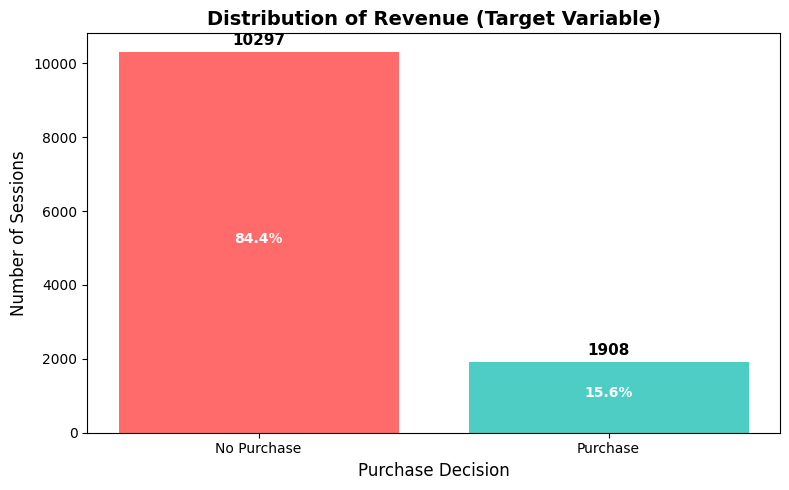

In [15]:
# visualize target variable distribution
plt.figure(figsize=(8, 5))
revenue_counts = df_clean['Revenue'].value_counts()
plt.bar(['No Purchase', 'Purchase'], revenue_counts.values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribution of Revenue (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Purchase Decision', fontsize=12)

# add value labels on bars
for i, v in enumerate(revenue_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


The target variable shows significant class imbalance with 84.4% non-purchase sessions and 15.6% purchase sessions. This imbalance is typical in e-commerce where most visitors browse without buying. This will be important to address during modeling, potentially using techniques like SMOTE or class weighting.


##### **Administrative Pages**

Administrative pages typically include account management, login, and registration pages. Understanding how users interact with these pages can provide insights into user engagement.


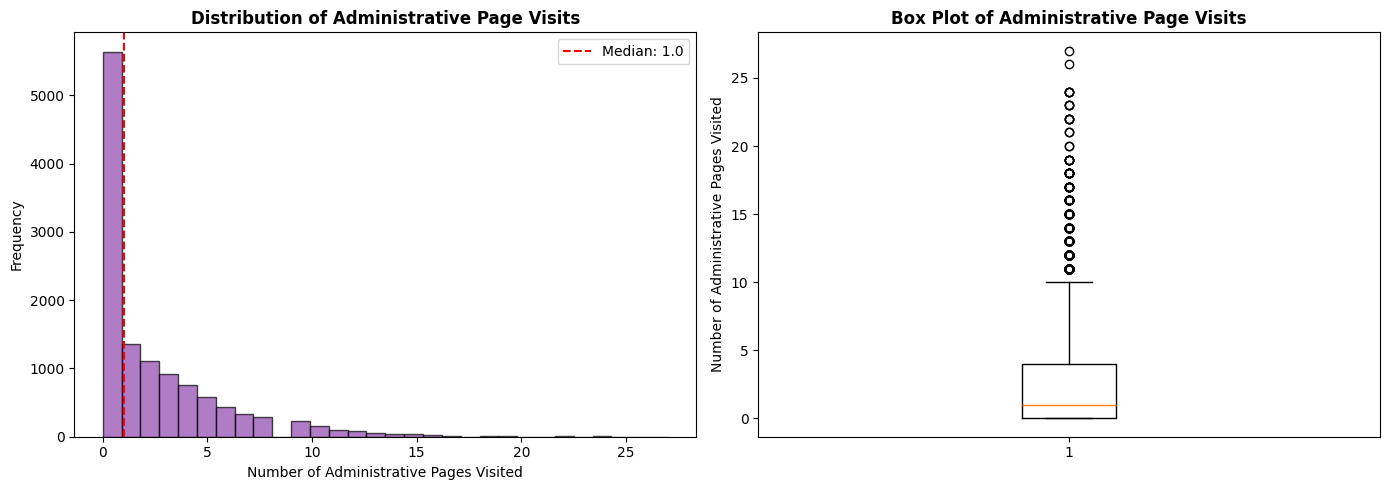

Mean: 2.34
Median: 1.00
Std: 3.33


In [16]:
# distribution of Administrative pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative'], bins=30, color='#8e44ad', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Administrative Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative'], vert=True)
axes[1].set_title('Box Plot of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Administrative Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative'].mean():.2f}")
print(f"Median: {df_clean['Administrative'].median():.2f}")
print(f"Std: {df_clean['Administrative'].std():.2f}")

Administrative pages show a heavily right-skewed distribution with a median of 1 page. Most users visit very few administrative pages, which is expected as these are typically for account management. The outliers suggest some users engage more with account-related features, possibly during registration or checkout.


##### **Administrative_Duration**

This feature represents the total time spent on administrative pages during a session.


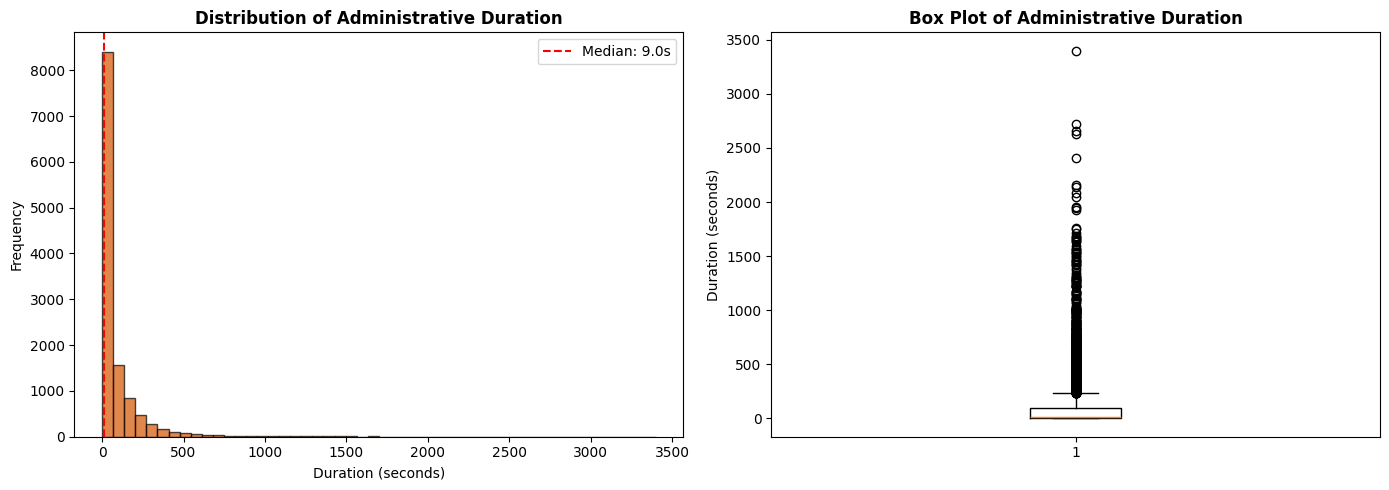

Mean: 81.65 seconds
Median: 9.00 seconds


In [17]:
# distribution of Administrative_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative_Duration'], bins=50, color='#d35400', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative_Duration'], vert=True)
axes[1].set_title('Box Plot of Administrative Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Administrative_Duration'].median():.2f} seconds")

Administrative duration is also right-skewed with a low median of 9 seconds. Most sessions spend minimal time on administrative pages. The presence of outliers indicates some users spend significantly longer, possibly completing account setup or dealing with issues.


##### **Informational Pages**

Informational pages include content like FAQs, shipping information, and about pages. These help users make informed decisions.


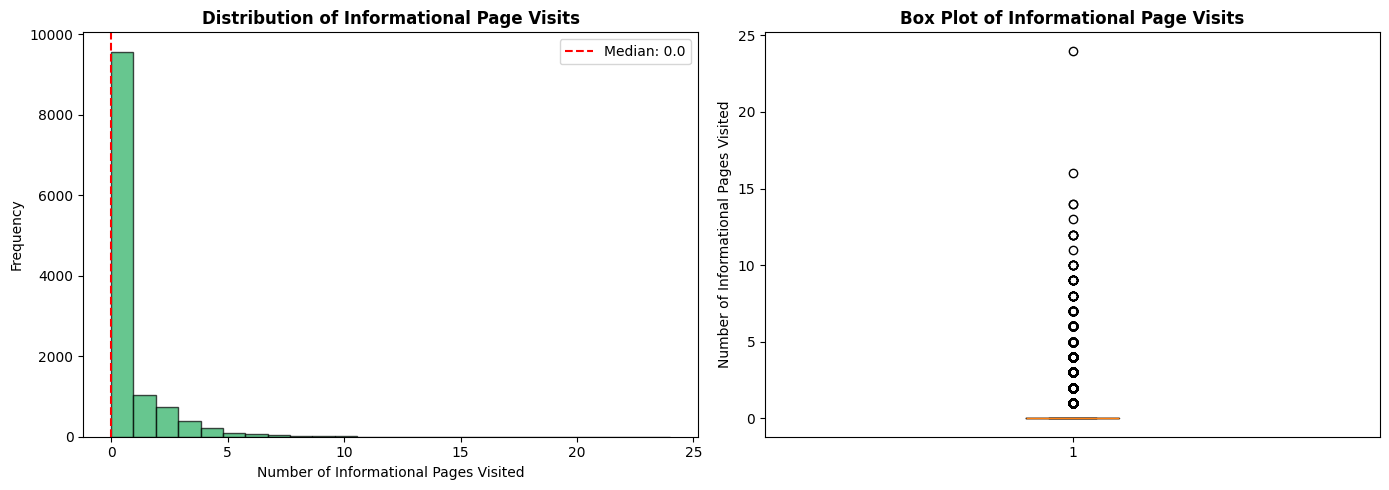

Mean: 0.51
Median: 0.00
Std: 1.28


In [18]:
# distribution of Informational pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational'], bins=25, color='#27ae60', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Informational Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Informational"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational'], vert=True)
axes[1].set_title('Box Plot of Informational Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Informational Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational'].mean():.2f}")
print(f"Median: {df_clean['Informational'].median():.2f}")
print(f"Std: {df_clean['Informational'].std():.2f}")

Informational pages show an even more extreme distribution with a median of 0, meaning most users skip informational pages entirely. Only a small portion of users seek out FAQs or shipping information, suggesting they may already be familiar with the site or prefer to browse products directly.


##### **Informational_Duration**

This measures the time spent reading informational content during a session.


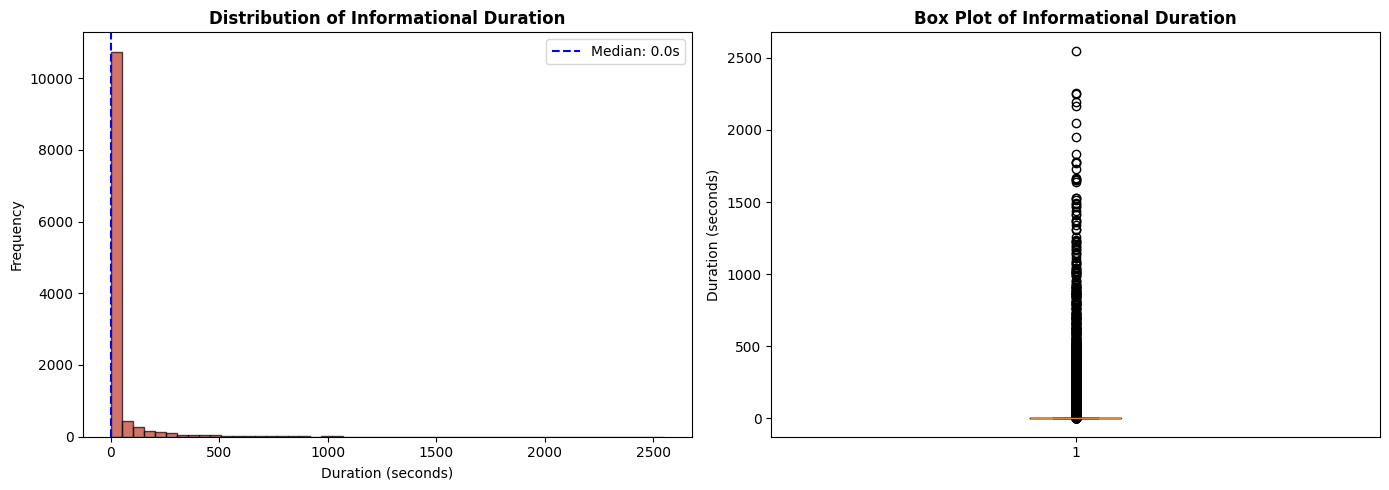

Mean: 34.83 seconds
Median: 0.00 seconds


In [19]:
# distribution of Informational_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational_Duration'], bins=50, color='#c0392b', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational_Duration'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["Informational_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational_Duration'], vert=True)
axes[1].set_title('Box Plot of Informational Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Informational_Duration'].median():.2f} seconds")

Informational duration has a median of 0 seconds, confirming that most sessions do not interact with informational content. When users do access these pages, there is high variability in time spent, as shown by the outliers.


##### **Product-Related Features**

These features track user interaction with product pages, which are likely strong predictors of purchase behavior.


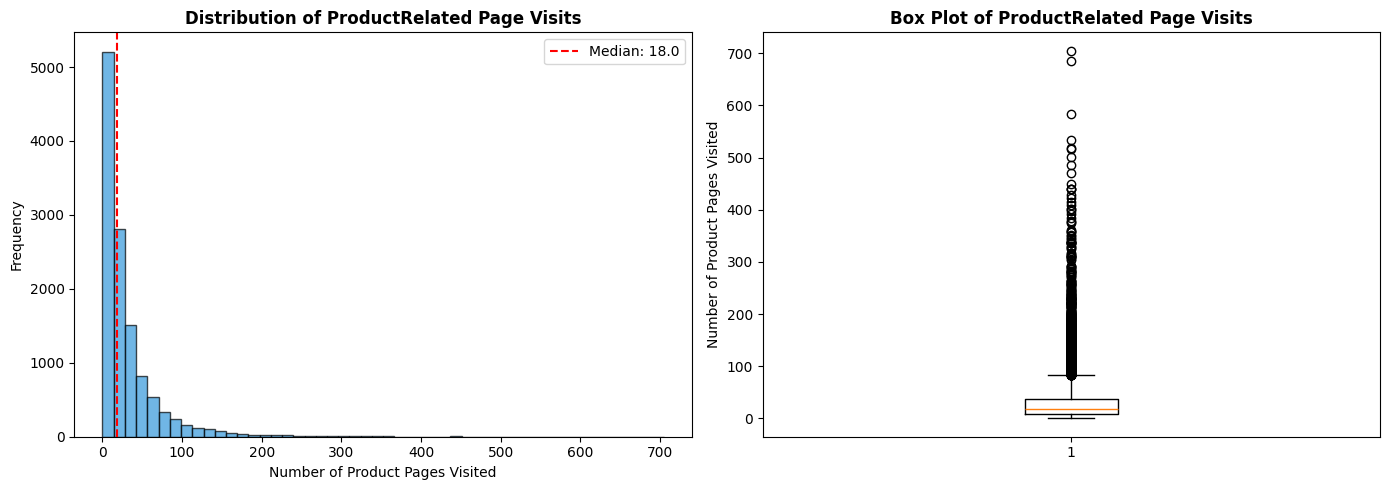

Mean: 32.05
Median: 18.00
Std: 44.59


In [20]:
# distribution of ProductRelated pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ProductRelated'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Product Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated'].mean():.2f}")
print(f"Median: {df_clean['ProductRelated'].median():.2f}")
print(f"Std: {df_clean['ProductRelated'].std():.2f}")


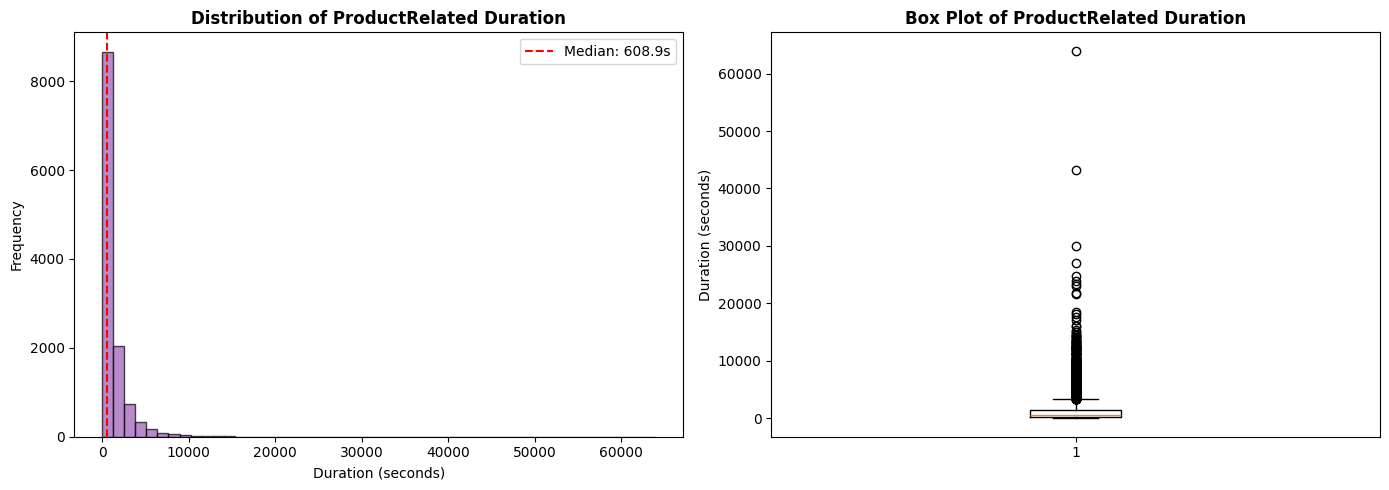

Mean: 1206.98 seconds
Median: 608.94 seconds


In [21]:
# distribution of ProductRelated_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram with log scale for better visualization
axes[0].hist(df_clean['ProductRelated_Duration'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated_Duration'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['ProductRelated_Duration'].median():.2f} seconds")


The ProductRelated features show right-skewed distributions. Most users visit around 18 product pages (median) with a mean of 31.7 pages, indicating some users browse extensively. The duration also shows high variability with a median of 609 seconds (about 10 minutes). The presence of many outliers in the boxplot suggests diverse browsing behaviors, which may be useful for clustering analysis.


##### **BounceRates (Engagement Metric)**

BounceRate indicates the percentage of visitors who leave immediately. Lower bounce rates typically suggest better engagement.


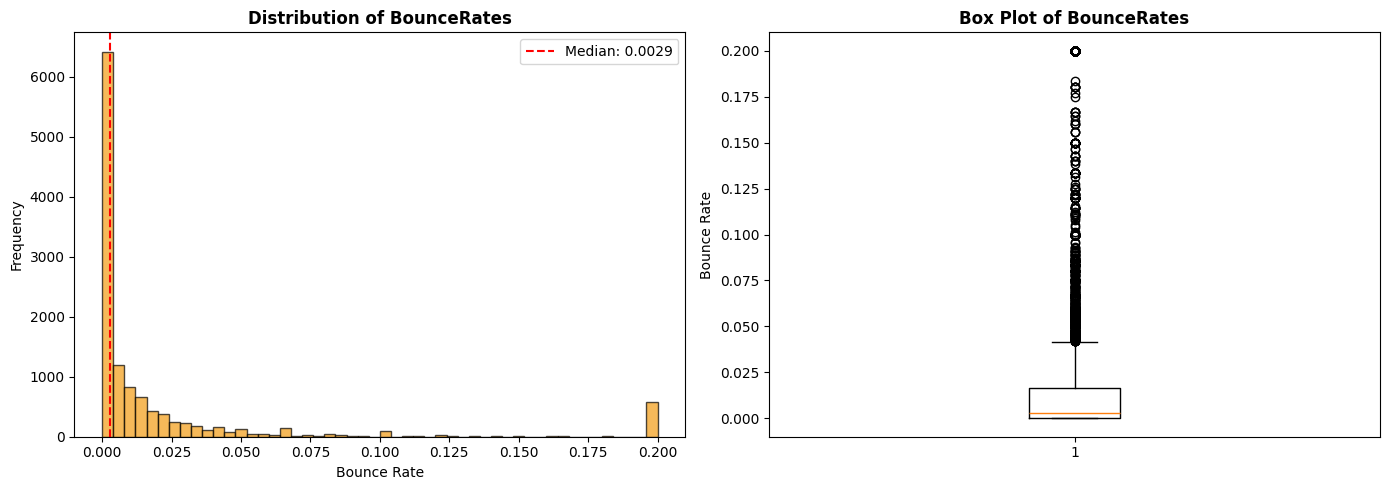

Mean: 0.0204
Median: 0.0029


In [22]:
# distribution of BounceRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['BounceRates'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of BounceRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bounce Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['BounceRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["BounceRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['BounceRates'], vert=True)
axes[1].set_title('Box Plot of BounceRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bounce Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['BounceRates'].mean():.4f}")
print(f"Median: {df_clean['BounceRates'].median():.4f}")

BounceRates show that most sessions have very low bounce rates (median 0.0029), indicating users generally engage with multiple pages. The presence of outliers at higher bounce rates suggests some sessions with poor engagement.


##### **ExitRates (Session Ending Metric)**

ExitRate measures the percentage of pageviews that were the last in the session. This helps identify pages where users leave the site.


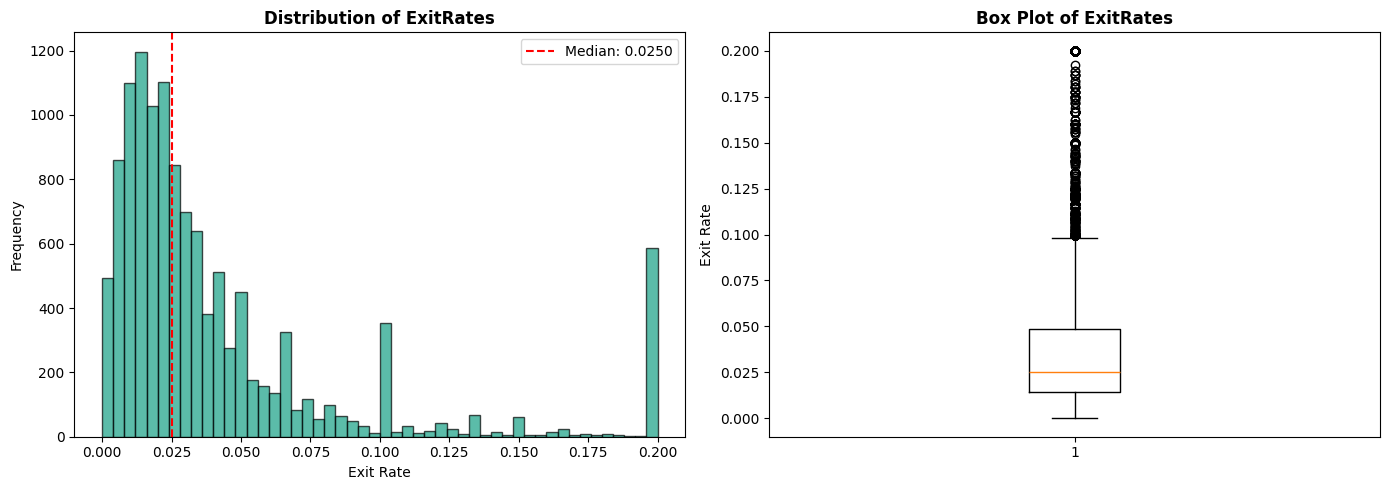

Mean: 0.0415
Median: 0.0250


In [23]:
# distribution of ExitRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ExitRates'], bins=50, color='#16a085', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ExitRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Exit Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ExitRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ExitRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ExitRates'], vert=True)
axes[1].set_title('Box Plot of ExitRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ExitRates'].mean():.4f}")
print(f"Median: {df_clean['ExitRates'].median():.4f}")

ExitRates have a median of 0.025 with more spread than BounceRates. The distribution shows that exit behavior varies significantly across sessions, which may help differentiate between purchasers and non-purchasers.


##### **PageValues (Transaction Value Indicator)**

PageValues represents the average value of pages visited before a transaction. This is a critical feature as it directly relates to purchase intent.


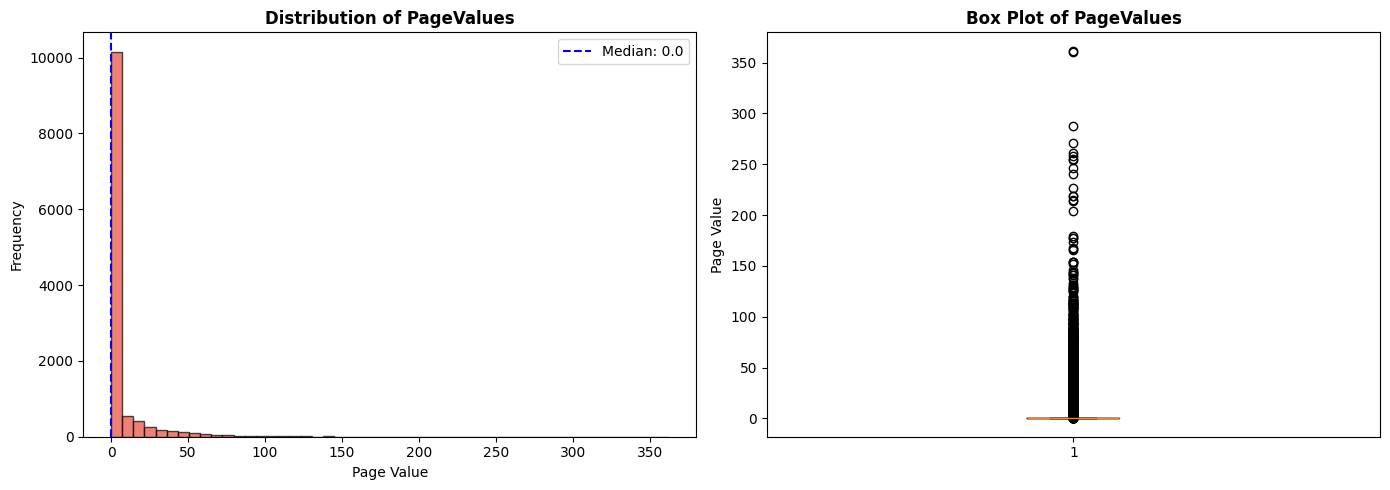

Mean: 5.95
Median: 0.00
Non-zero PageValues: 2730 (22.4%)


In [24]:
# distribution of PageValues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['PageValues'], bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of PageValues', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Page Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['PageValues'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["PageValues"].median():.1f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['PageValues'], vert=True)
axes[1].set_title('Box Plot of PageValues', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Page Value', fontsize=10)

plt.tight_layout()
plt.show()

# statistics
print(f"Mean: {df_clean['PageValues'].mean():.2f}")
print(f"Median: {df_clean['PageValues'].median():.2f}")
print(f"Non-zero PageValues: {(df_clean['PageValues'] > 0).sum()} ({(df_clean['PageValues'] > 0).sum() / len(df_clean) * 100:.1f}%)")

PageValues is highly skewed with median of 0, meaning 77.6% of sessions have zero page value (no purchase intent tracked). Only 22.4% of sessions show non-zero values, which aligns with our purchase rate. This feature will be a strong predictor for classification.


##### **SpecialDay**

SpecialDay indicates the closeness of the session to special occasions like Valentine's Day or Mother's Day, which may influence shopping behavior.


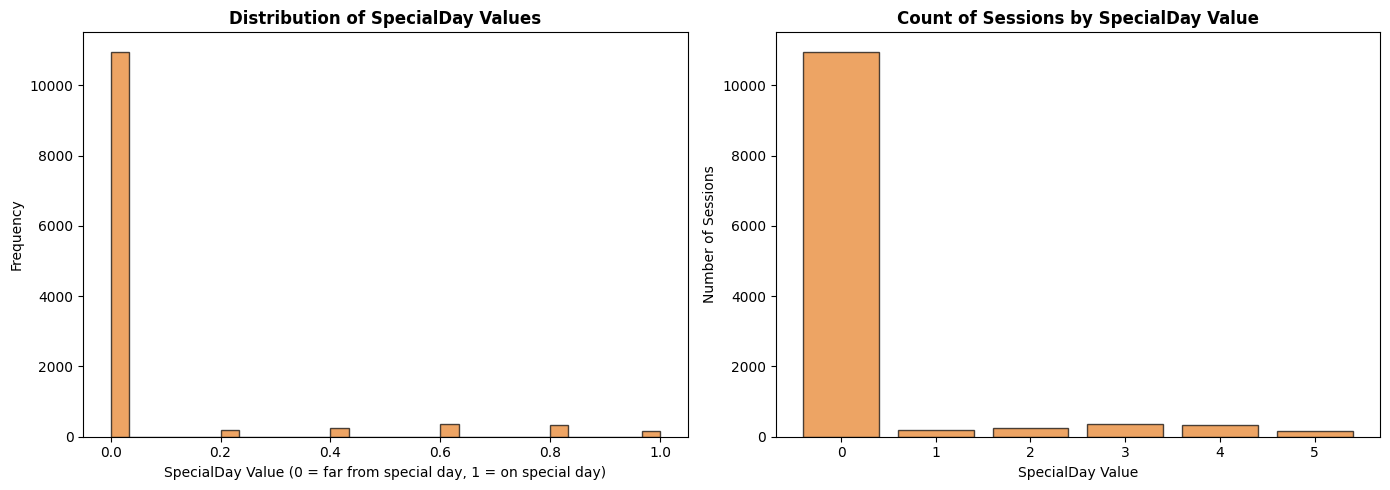

Mean: 0.0619
Median: 0.0000

Sessions with SpecialDay = 0: 10956 (89.8%)
Sessions with SpecialDay > 0: 1249 (10.2%)


In [25]:
# distribution of SpecialDay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['SpecialDay'], bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of SpecialDay Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SpecialDay Value (0 = far from special day, 1 = on special day)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)

# value counts
special_day_counts = df_clean['SpecialDay'].value_counts().sort_index()
axes[1].bar(range(len(special_day_counts)), special_day_counts.values, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_title('Count of Sessions by SpecialDay Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('SpecialDay Value', fontsize=10)
axes[1].set_ylabel('Number of Sessions', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['SpecialDay'].mean():.4f}")
print(f"Median: {df_clean['SpecialDay'].median():.4f}")
print(f"\nSessions with SpecialDay = 0: {(df_clean['SpecialDay'] == 0).sum()} ({(df_clean['SpecialDay'] == 0).sum() / len(df_clean) * 100:.1f}%)")
print(f"Sessions with SpecialDay > 0: {(df_clean['SpecialDay'] > 0).sum()} ({(df_clean['SpecialDay'] > 0).sum() / len(df_clean) * 100:.1f}%)")

SpecialDay shows that the vast majority of sessions occur far from special occasions (value = 0). Only a small number of sessions are close to special days like Valentine's Day or Mother's Day. This suggests most data was collected during regular shopping periods, though the few sessions near special days may show different purchasing patterns worth investigating in bivariate analysis.


##### **Month (Seasonal Patterns)**

Understanding the temporal distribution of sessions can reveal seasonal shopping trends.


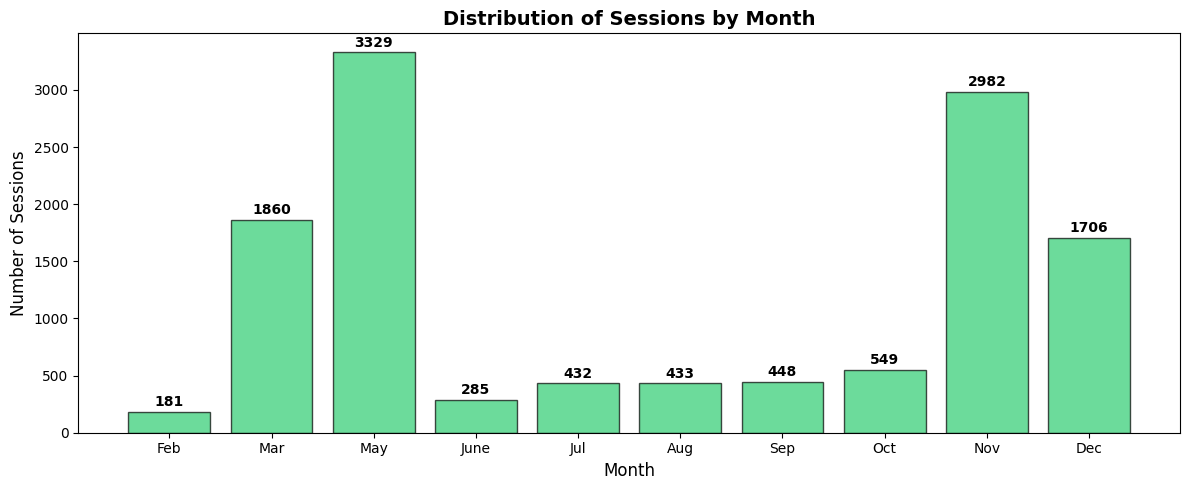


Session counts by month:
Month
Feb      181
Mar     1860
May     3329
June     285
Jul      432
Aug      433
Sep      448
Oct      549
Nov     2982
Dec     1706
Name: count, dtype: int64


In [26]:
# distribution of sessions by month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_counts = df_clean['Month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(month_counts.index, month_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(month_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by month:")
print(month_counts)

The bar chart shows that shopping activity peaks in **May and November**, with over 3,000 sessions each, suggesting strong seasonal trends potentially linked to shopping events. Activity is lowest in **February**, which might indicate post-holiday shopping fatigue. This **seasonal pattern** is important for understanding when users are most likely to visit the site.


##### **OperatingSystems**

Understanding which operating systems visitors use helps optimize website compatibility and user experience across different platforms.


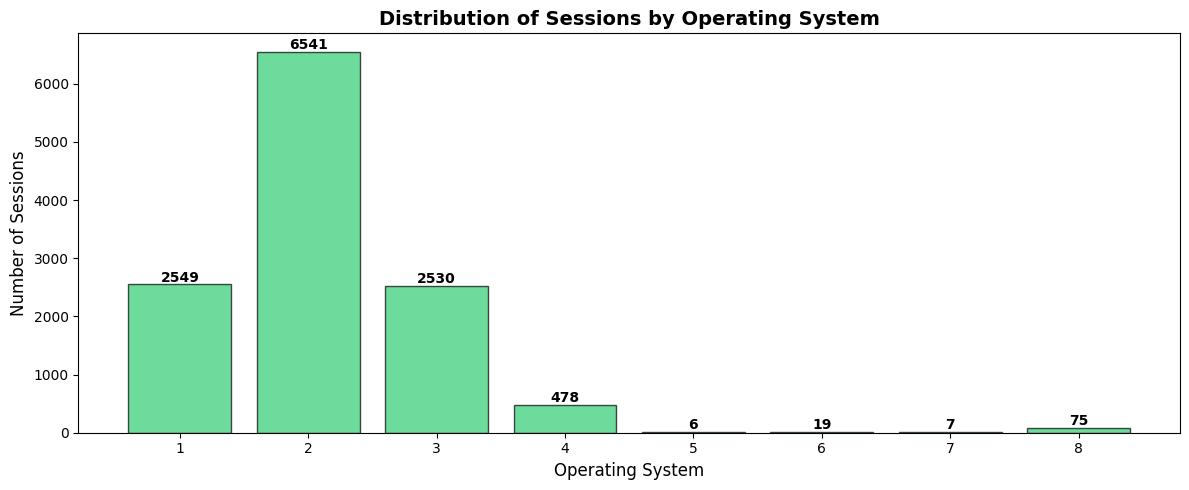


Session counts by Operating System:
OperatingSystems
1    2549
2    6541
3    2530
4     478
5       6
6      19
7       7
8      75
Name: count, dtype: int64


In [27]:
# distribution of sessions by OS
os_counts = df_clean['OperatingSystems'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(os_counts.index, os_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Operating System', fontsize=14, fontweight='bold')
plt.xlabel('Operating System', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(os_counts.values):
    plt.text(os_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Operating System:")
print(os_counts)

The operating system distribution shows **moderate class imbalance** with **OS 2** dominating at 4,500+ sessions (37%), **OS 1** and **OS 3** with 2,500-3,000 sessions each (20-24%), while OS 4-8 have minimal representation (<1,000 sessions). This distribution pattern suggests that OperatingSystems could provide moderate predictive value, as the top 3 OS platforms represent ~80% of traffic. However, rare OS categories may need to be grouped into an "Other" category during feature engineering to prevent overfitting and improve model generalization. For clustering analysis, OS differences may help segment users by device/platform preferences alongside behavioral patterns.


##### **Browser**

Browser indicates which web browser visitors use to access the site.


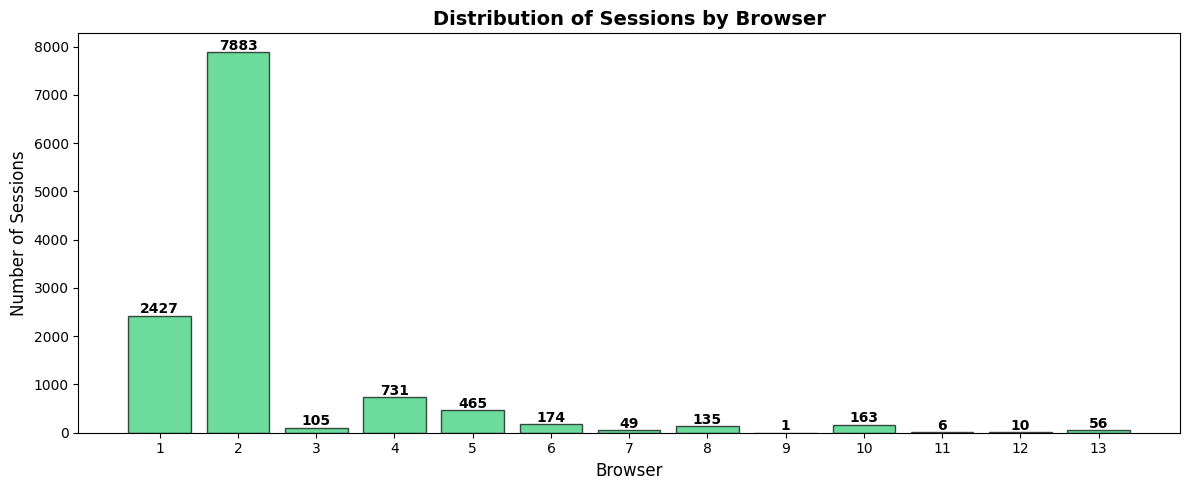


Session counts by Browser:
Browser
1     2427
2     7883
3      105
4      731
5      465
6      174
7       49
8      135
9        1
10     163
11       6
12      10
13      56
Name: count, dtype: int64


In [28]:
# distribution of sessions by Browser
browser_counts = df_clean['Browser'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(browser_counts.index, browser_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Browser', fontsize=14, fontweight='bold')
plt.xlabel('Browser', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all browser IDs on x-axis
plt.xticks(browser_counts.index)

# add value labels on bars
for i, v in enumerate(browser_counts.values):
    plt.text(browser_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Browser:")
print(browser_counts)

The browser distribution reveals **extreme class imbalance** with **Browser 2** dominating at over 5,000 sessions (41%), **Browser 1** with approximately 2,000 sessions (16%), while browsers 3-13 each have fewer than 500 sessions. This **highly skewed distribution** creates a modeling challenge, as browsers with minimal representation may not provide sufficient signal for predicting purchasing behavior. For classification and clustering tasks, this suggests Browser may have limited predictive power as a standalone feature, though interaction effects with other variables could still be valuable. Feature engineering approaches such as grouping rare browsers or treating Browser as a binary feature (major vs. minor) may improve model performance.


##### **Region**

Region represents the geographical location of visitors accessing the e-commerce site. Analyzing regional distribution helps identify key markets and supports targeted regional marketing strategies.


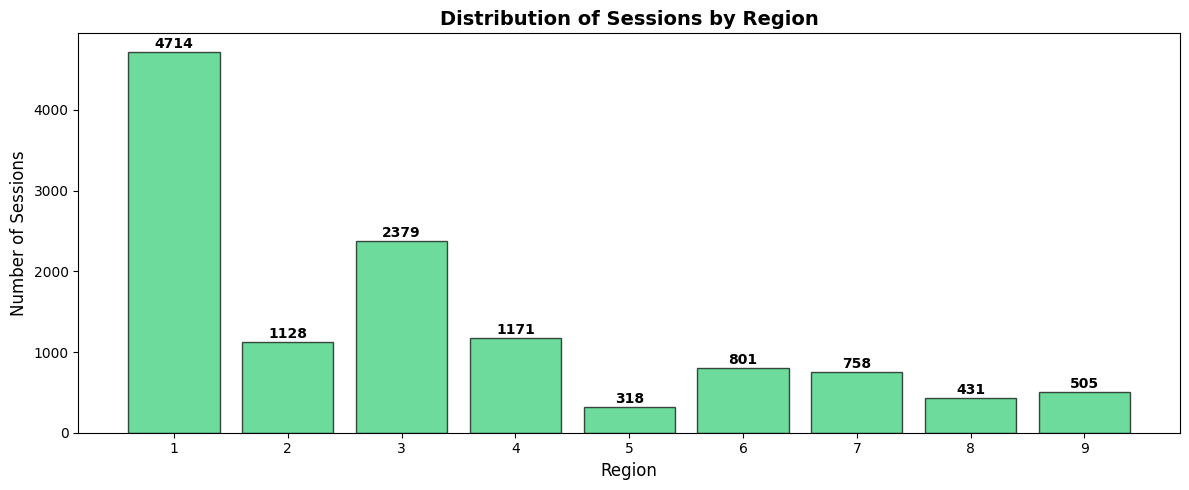


Session counts by Region:
Region
1    4714
2    1128
3    2379
4    1171
5     318
6     801
7     758
8     431
9     505
Name: count, dtype: int64


In [29]:
# distribution of sessions by Region
region_counts = df_clean['Region'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(region_counts.index, region_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all region IDs on x-axis
plt.xticks(region_counts.index)

# add value labels on bars
for i, v in enumerate(region_counts.values):
    plt.text(region_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Region:")
print(region_counts)

The regional distribution exhibits **high cardinality** with 9 regions showing varied representation: **Region 1** leads with ~3,500 sessions (28%), **Region 3** with ~2,000 sessions (16%), and several moderate regions with 500-1,500 sessions. This geographic diversity presents both opportunities and challenges. The relatively balanced distribution across multiple regions (compared to Browser/OS) suggests Region could be a useful feature for both classification and clustering tasks, potentially capturing location-based purchasing patterns. However, regions with very low counts may benefit from grouping or regularization techniques. In clustering, regional patterns combined with behavioral metrics could reveal geographically-distinct customer segments.


##### **TrafficType**

TrafficType indicates the source channel through which visitors arrived at the site (e.g., direct traffic, search engines, social media, referrals, or paid advertising). Understanding traffic sources helps optimize marketing channels and acquisition strategies.


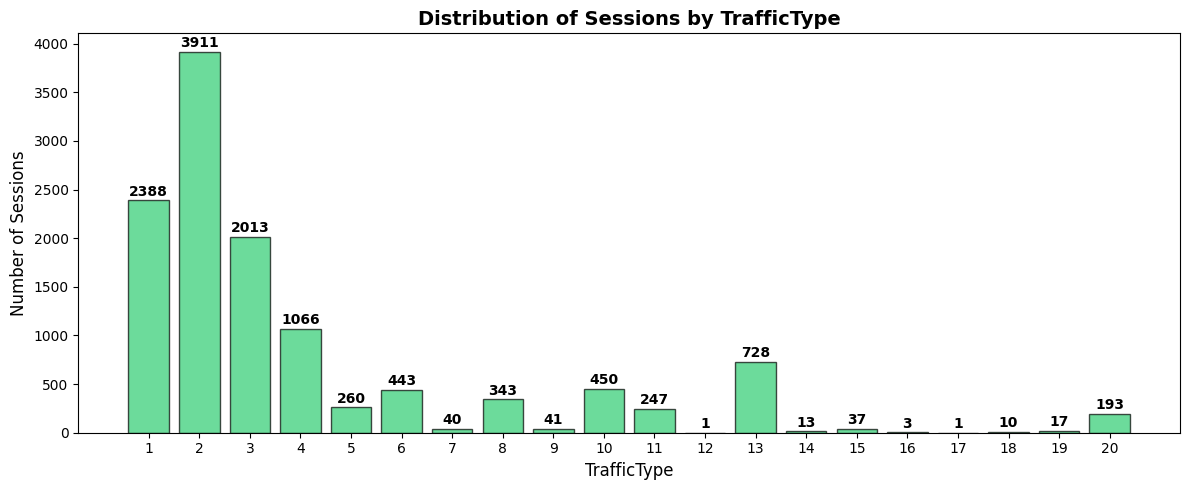


Session counts by TrafficType:
TrafficType
1     2388
2     3911
3     2013
4     1066
5      260
6      443
7       40
8      343
9       41
10     450
11     247
12       1
13     728
14      13
15      37
16       3
17       1
18      10
19      17
20     193
Name: count, dtype: int64


In [30]:

# distribution of sessions by TrafficType
traffic_counts = df_clean['TrafficType'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(traffic_counts.index, traffic_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by TrafficType', fontsize=14, fontweight='bold')
plt.xlabel('TrafficType', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all TrafficType IDs on x-axis
plt.xticks(traffic_counts.index)

# add value labels on bars
for i, v in enumerate(traffic_counts.values):
    plt.text(traffic_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by TrafficType:")
print(traffic_counts)

The traffic type distribution shows **very high cardinality** with 20 distinct traffic sources, where **Traffic Type 2** dominates (4,000+ sessions, 33%), followed by **Types 1 and 3** (~2,000 sessions each, 16% each), while most others have <1,000 sessions. This **extremely sparse feature space** presents significant modeling challenges: many rare traffic types provide insufficient samples for reliable pattern learning. For **classification models**, this suggests TrafficType should undergo aggressive dimensionality reduction—either grouping rare categories (e.g., "Top 3" vs "Other") or using target encoding to capture purchase likelihood per traffic source. For **clustering**, traffic source may help identify acquisition-based segments but should be combined with behavioral features to avoid over-segmentation.


##### **VisitorType (User Segmentation)**

VisitorType categorizes users as returning visitors, new visitors, or other. This may influence purchase behavior.


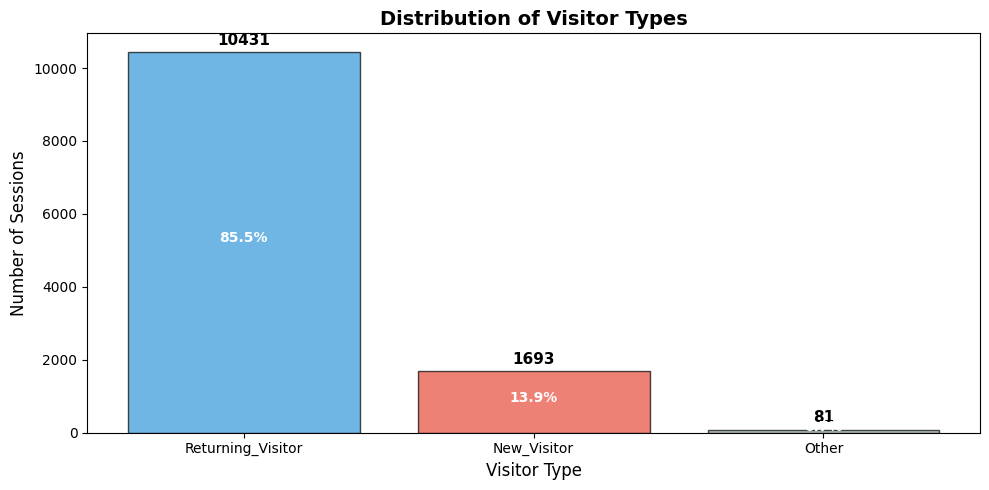

Visitor type distribution:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Percentages:
VisitorType
Returning_Visitor    85.464973
New_Visitor          13.871364
Other                 0.663662
Name: count, dtype: float64


In [31]:
# distribution of VisitorType
visitor_counts = df_clean['VisitorType'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(visitor_counts.index, visitor_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Visitor Types', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(visitor_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visitor type distribution:")
print(visitor_counts)
print(f"\nPercentages:")
print(visitor_counts / len(df_clean) * 100)


The majority of sessions are from returning visitors (85.5%), with only 13.9% from new visitors. This suggests the website has a strong repeat visitor base. The "Other" category is minimal (0.7%). This imbalance may influence purchase patterns and will be important for clustering analysis.


##### **Weekend (Temporal Pattern)**

Understanding whether sessions occur on weekends versus weekdays may reveal different shopping behaviors.


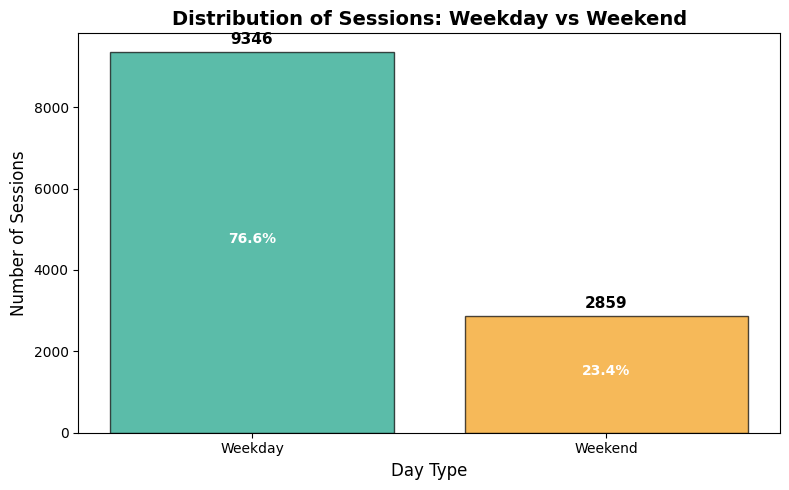

Weekend distribution:
Weekend
False    9346
True     2859
Name: count, dtype: int64

Percentages:
Weekend
False    76.575174
True     23.424826
Name: count, dtype: float64


In [32]:
# distribution of Weekend sessions
weekend_counts = df_clean['Weekend'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Weekday', 'Weekend'], weekend_counts.values, color=['#16a085', '#f39c12'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(weekend_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Weekend distribution:")
print(weekend_counts)
print(f"\nPercentages:")
print(weekend_counts / len(df_clean) * 100)


Most sessions occur on weekdays (76.6%) compared to weekends (23.4%). This is expected for online shopping, though weekend sessions might show different purchasing behaviors worth investigating in bivariate analysis.


#### **b. Bivariate Analysis**

Now we examine relationships between features and our target variable (Revenue). This analysis will help us identify which features are most predictive of purchase behavior and guide our feature selection for modeling.


##### **Revenue vs PageValues**

From our univariate analysis, we found that PageValues has a median of 0 with only 22.4% non-zero values, which closely matches our purchase rate of 15.6%. We hypothesize that PageValues will be a strong predictor of purchase behavior.


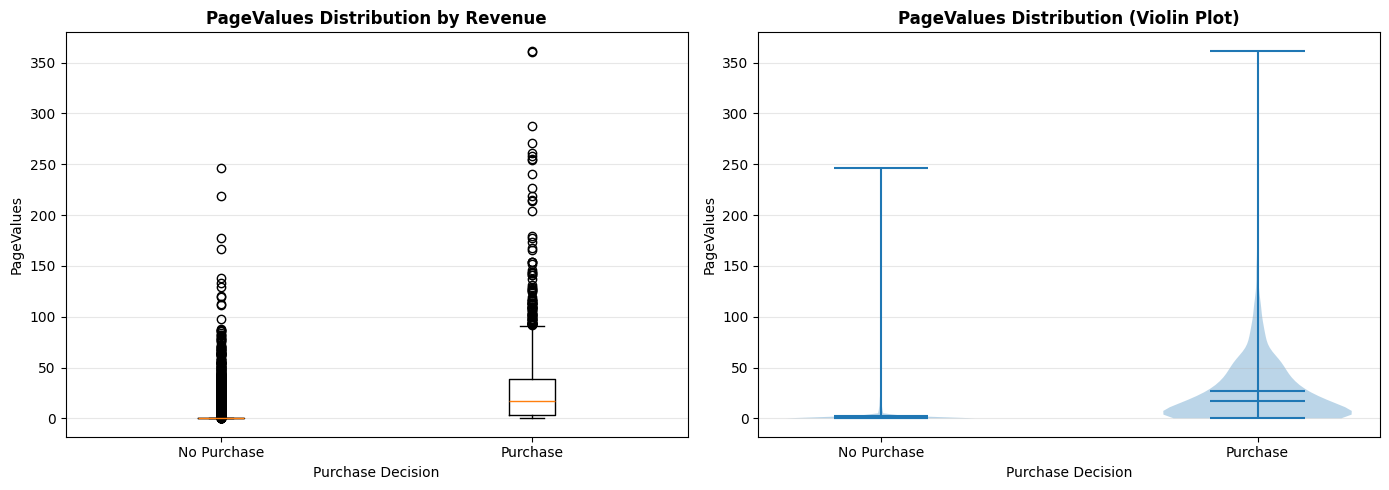

PageValues Statistics by Revenue:

No Purchase Group:
  Mean: 2.00
  Median: 0.00
  Non-zero count: 1192 (11.6%)

Purchase Group:
  Mean: 27.26
  Median: 16.76
  Non-zero count: 1538 (80.6%)


In [33]:
# compare PageValues between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot comparison
purchase_data = df_clean[df_clean['Revenue'] == True]['PageValues']
no_purchase_data = df_clean[df_clean['Revenue'] == False]['PageValues']

axes[0].boxplot([no_purchase_data, purchase_data], labels=['No Purchase', 'Purchase'])
axes[0].set_title('PageValues Distribution by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PageValues', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# violin plot for better distribution view
purchase_df = df_clean.copy()
purchase_df['Revenue_Label'] = purchase_df['Revenue'].map({False: 'No Purchase', True: 'Purchase'})
axes[1].violinplot([no_purchase_data, purchase_data], positions=[0, 1], showmeans=True, showmedians=True)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Purchase', 'Purchase'])
axes[1].set_title('PageValues Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PageValues', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical summary
print("PageValues Statistics by Revenue:\n")
print("No Purchase Group:")
print(f"  Mean: {no_purchase_data.mean():.2f}")
print(f"  Median: {no_purchase_data.median():.2f}")
print(f"  Non-zero count: {(no_purchase_data > 0).sum()} ({(no_purchase_data > 0).sum() / len(no_purchase_data) * 100:.1f}%)")

print("\nPurchase Group:")
print(f"  Mean: {purchase_data.mean():.2f}")
print(f"  Median: {purchase_data.median():.2f}")
print(f"  Non-zero count: {(purchase_data > 0).sum()} ({(purchase_data > 0).sum() / len(purchase_data) * 100:.1f}%)")

**KEY FINDING:** PageValues shows a dramatic difference between purchase and no-purchase groups. The purchase group has a mean PageValues of 27.26 (13.6x higher than no-purchase at 2.00) and a median of 16.76 (compared to 0 for no-purchase). Most importantly, 80.6% of purchases have non-zero PageValues, while only 11.6% of non-purchases do. This confirms PageValues is likely our strongest predictor - it directly measures the value of pages visited before transaction, making it an excellent indicator of purchase intent. This feature will be critical for our classification model.


##### **Revenue vs ProductRelated Features**

Product-related pages are where users view items for purchase. We expect users who make purchases to visit more product pages and spend more time browsing products.


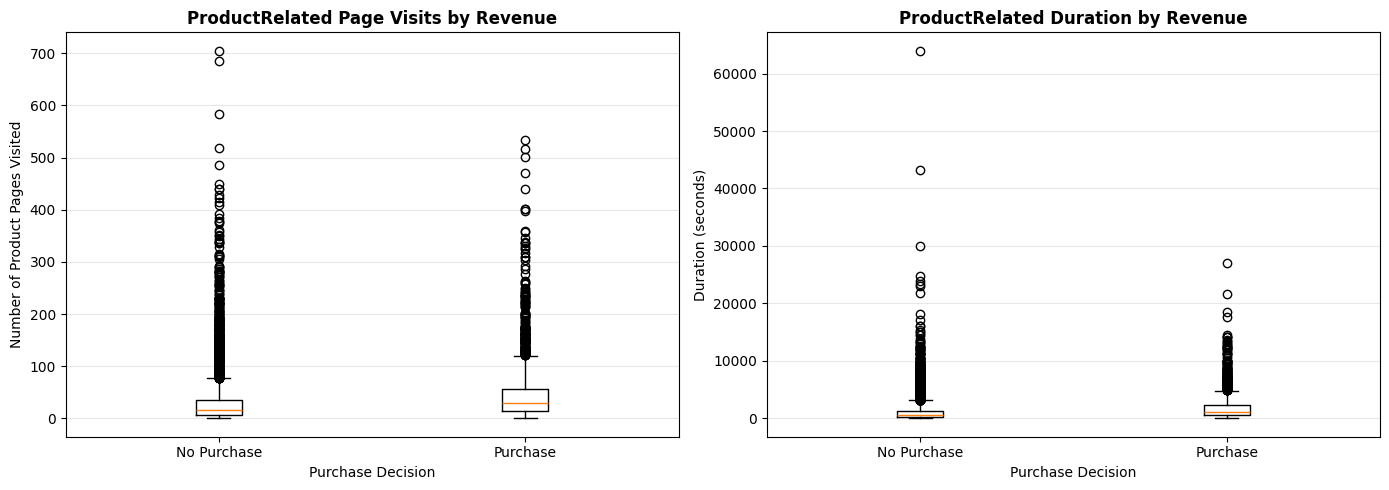

ProductRelated Page Visits by Revenue:

No Purchase - Mean: 29.05, Median: 16.00
Purchase - Mean: 48.21, Median: 29.00
Difference: 19.16 pages (66.0% increase)


ProductRelated Duration by Revenue:

No Purchase - Mean: 1082.98s, Median: 526.00s
Purchase - Mean: 1876.21s, Median: 1109.91s
Difference: 793.23 seconds (73.2% increase)


In [34]:
# compare ProductRelated features between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ProductRelated page visits
pr_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated']
pr_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated']

axes[0].boxplot([pr_no_purchase, pr_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('ProductRelated Page Visits by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ProductRelated Duration
prd_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated_Duration']
prd_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated_Duration']

axes[1].boxplot([prd_no_purchase, prd_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ProductRelated Duration by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("ProductRelated Page Visits by Revenue:\n")
print(f"No Purchase - Mean: {pr_no_purchase.mean():.2f}, Median: {pr_no_purchase.median():.2f}")
print(f"Purchase - Mean: {pr_purchase.mean():.2f}, Median: {pr_purchase.median():.2f}")
print(f"Difference: {pr_purchase.mean() - pr_no_purchase.mean():.2f} pages ({((pr_purchase.mean() / pr_no_purchase.mean() - 1) * 100):.1f}% increase)")

print("\n" + "="*60 + "\n")

print("ProductRelated Duration by Revenue:\n")
print(f"No Purchase - Mean: {prd_no_purchase.mean():.2f}s, Median: {prd_no_purchase.median():.2f}s")
print(f"Purchase - Mean: {prd_purchase.mean():.2f}s, Median: {prd_purchase.median():.2f}s")
print(f"Difference: {prd_purchase.mean() - prd_no_purchase.mean():.2f} seconds ({((prd_purchase.mean() / prd_no_purchase.mean() - 1) * 100):.1f}% increase)")

**KEY FINDING:** Purchasers show significantly higher engagement with product pages. They visit 66% more product pages (48.2 vs 29.1 pages) and spend 73.2% more time browsing products (1876s vs 1083s, roughly 31 minutes vs 18 minutes). The boxplots show clear separation between the two groups, though with substantial overlap and outliers. This indicates that while product browsing behavior is predictive of purchases, it's not as definitive as PageValues. Users who spend more time exploring products are more likely to purchase, but the relationship is not absolute.


##### **Revenue vs Engagement Metrics**

BounceRates and ExitRates measure user engagement quality. We expect purchasers to have lower bounce and exit rates, indicating better engagement with the site.


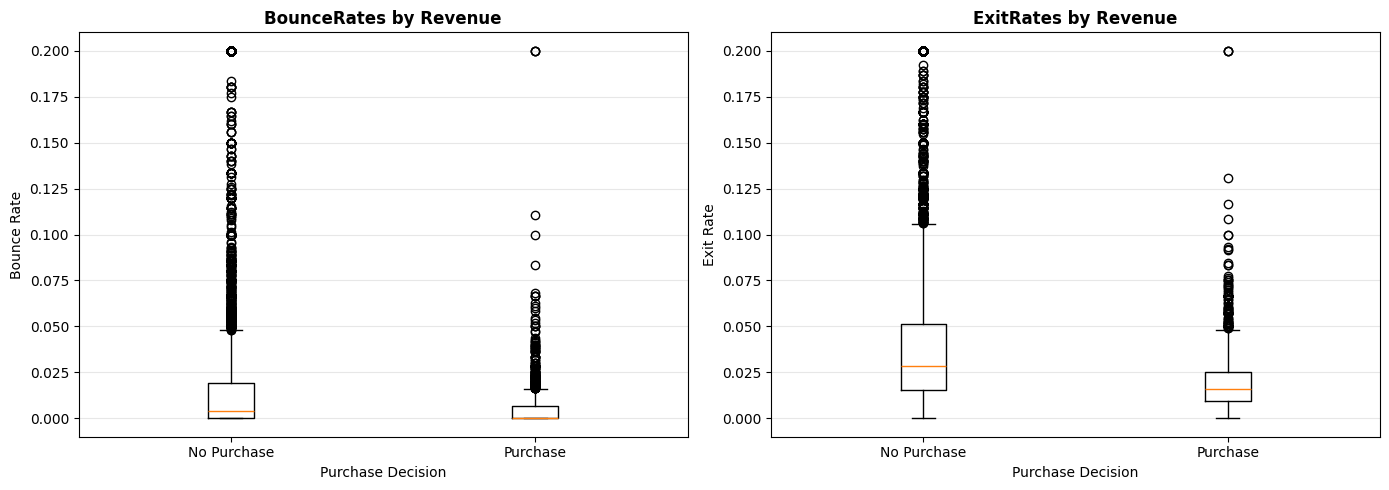

BounceRates by Revenue:

No Purchase - Mean: 0.0232, Median: 0.0039
Purchase - Mean: 0.0051, Median: 0.0000
Difference: 0.0181 (No Purchase is 353.3% higher)


ExitRates by Revenue:

No Purchase - Mean: 0.0455, Median: 0.0284
Purchase - Mean: 0.0196, Median: 0.0160
Difference: 0.0260 (No Purchase is 132.8% higher)


In [35]:
# compare engagement metrics between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BounceRates
br_purchase = df_clean[df_clean['Revenue'] == True]['BounceRates']
br_no_purchase = df_clean[df_clean['Revenue'] == False]['BounceRates']

axes[0].boxplot([br_no_purchase, br_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('BounceRates by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Bounce Rate', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ExitRates
er_purchase = df_clean[df_clean['Revenue'] == True]['ExitRates']
er_no_purchase = df_clean[df_clean['Revenue'] == False]['ExitRates']

axes[1].boxplot([er_no_purchase, er_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ExitRates by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("BounceRates by Revenue:\n")
print(f"No Purchase - Mean: {br_no_purchase.mean():.4f}, Median: {br_no_purchase.median():.4f}")
print(f"Purchase - Mean: {br_purchase.mean():.4f}, Median: {br_purchase.median():.4f}")
print(f"Difference: {br_no_purchase.mean() - br_purchase.mean():.4f} (No Purchase is {((br_no_purchase.mean() / br_purchase.mean() - 1) * 100):.1f}% higher)")

print("\n" + "="*60 + "\n")

print("ExitRates by Revenue:\n")
print(f"No Purchase - Mean: {er_no_purchase.mean():.4f}, Median: {er_no_purchase.median():.4f}")
print(f"Purchase - Mean: {er_purchase.mean():.4f}, Median: {er_purchase.median():.4f}")
print(f"Difference: {er_no_purchase.mean() - er_purchase.mean():.4f} (No Purchase is {((er_no_purchase.mean() / er_purchase.mean() - 1) * 100):.1f}% higher)")

**KEY FINDING:** The engagement metrics strongly differentiate purchasers from non-purchasers. Purchasers have dramatically lower BounceRates (0.0051 vs 0.0232, which is 353.3% lower) with a median of 0, meaning most purchasers engage with multiple pages rather than bouncing. Similarly, ExitRates are 132.8% lower for purchasers (0.0196 vs 0.0455). These metrics confirm that sustained engagement is a strong indicator of purchase intent. Users who bounce or exit quickly are much less likely to complete a purchase, making these valuable features for our classification model.


##### **Revenue vs Temporal Patterns**

We now examine whether purchase rates vary by time of visit. From our univariate analysis, we found strong seasonality in traffic (May and November peaks) and more weekday than weekend sessions. We want to see if conversion rates also differ across these temporal dimensions.


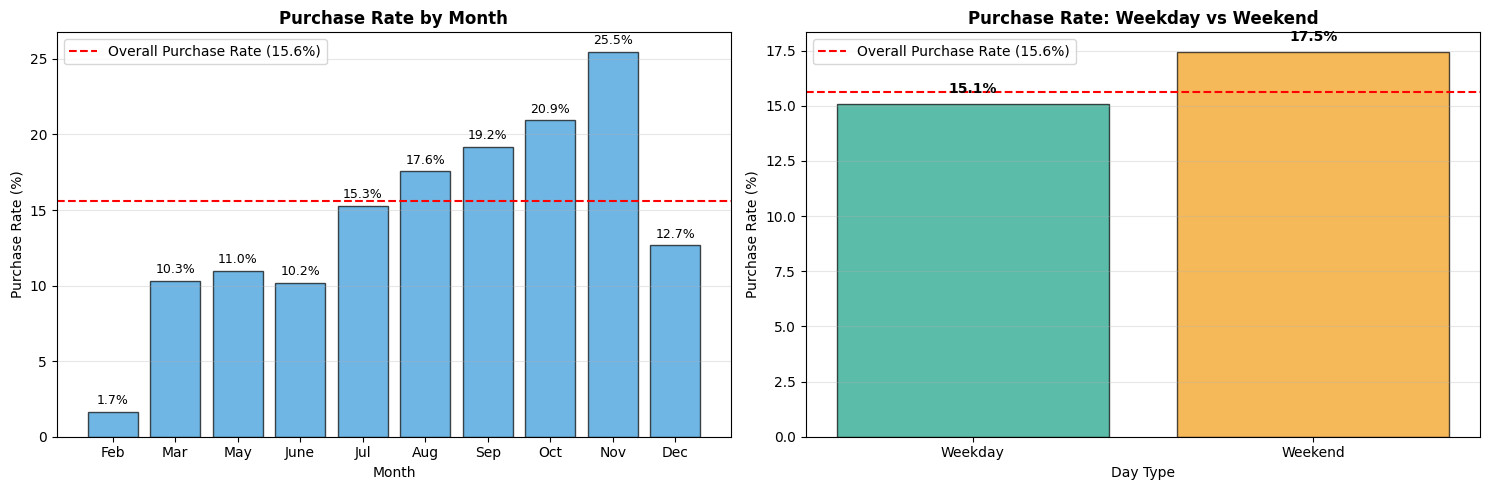

Purchase Rate by Month:

Feb   :  1.66% (   3 purchases /  181 sessions)
Mar   : 10.32% ( 192 purchases / 1860 sessions)
May   : 10.96% ( 365 purchases / 3329 sessions)
June  : 10.18% (  29 purchases /  285 sessions)
Jul   : 15.28% (  66 purchases /  432 sessions)
Aug   : 17.55% (  76 purchases /  433 sessions)
Sep   : 19.20% (  86 purchases /  448 sessions)
Oct   : 20.95% ( 115 purchases /  549 sessions)
Nov   : 25.49% ( 760 purchases / 2982 sessions)
Dec   : 12.66% ( 216 purchases / 1706 sessions)


Purchase Rate by Weekend:

Weekday: 15.08% (1409 purchases / 9346 sessions)
Weekend: 17.45% (499 purchases / 2859 sessions)


In [36]:
# calculate purchase rates by Month and Weekend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# purchase rate by Month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue = df_clean.groupby('Month')['Revenue'].agg(['sum', 'count'])
month_revenue['purchase_rate'] = (month_revenue['sum'] / month_revenue['count']) * 100
month_revenue = month_revenue.reindex(month_order)

axes[0].bar(month_revenue.index, month_revenue['purchase_rate'], color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Purchase Rate by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[0].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(month_revenue['purchase_rate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# purchase rate by Weekend
weekend_revenue = df_clean.groupby('Weekend')['Revenue'].agg(['sum', 'count'])
weekend_revenue['purchase_rate'] = (weekend_revenue['sum'] / weekend_revenue['count']) * 100

axes[1].bar(['Weekday', 'Weekend'], weekend_revenue['purchase_rate'].values, 
            color=['#16a085', '#f39c12'], edgecolor='black', alpha=0.7)
axes[1].set_title('Purchase Rate: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day Type', fontsize=10)
axes[1].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[1].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(weekend_revenue['purchase_rate'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Month:\n")
for month in month_order:
    rate = month_revenue.loc[month, 'purchase_rate']
    count = month_revenue.loc[month, 'count']
    purchases = month_revenue.loc[month, 'sum']
    print(f"{month:6s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):4d} sessions)")

print("\n" + "="*60 + "\n")

print("Purchase Rate by Weekend:\n")
print(f"Weekday: {weekend_revenue.loc[False, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[False, 'sum'])} purchases / {int(weekend_revenue.loc[False, 'count'])} sessions)")
print(f"Weekend: {weekend_revenue.loc[True, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[True, 'sum'])} purchases / {int(weekend_revenue.loc[True, 'count'])} sessions)")

**KEY FINDING:** Temporal patterns reveal significant variation in purchase behavior. Purchase rates vary dramatically by month, ranging from just 1.7% in February to 25.5% in November. There's a clear upward trend from summer through fall, with July-November all exceeding the overall 15.6% rate. November shows exceptional conversion (25.5%), likely due to holiday shopping and promotional events. This suggests seasonality is an important predictor.

Interestingly, weekend sessions have a slightly higher conversion rate (17.5% vs 15.1%), indicating weekend shoppers may be more purchase-ready than weekday browsers. These temporal features should be included in our classification model as they capture behavioral differences across time periods.


##### **Revenue vs Visitor Characteristics**

Finally, we examine how visitor type influences purchase behavior. Our univariate analysis showed 85.5% returning visitors and 13.9% new visitors. We want to determine if returning visitors, who are familiar with the site, have higher conversion rates.


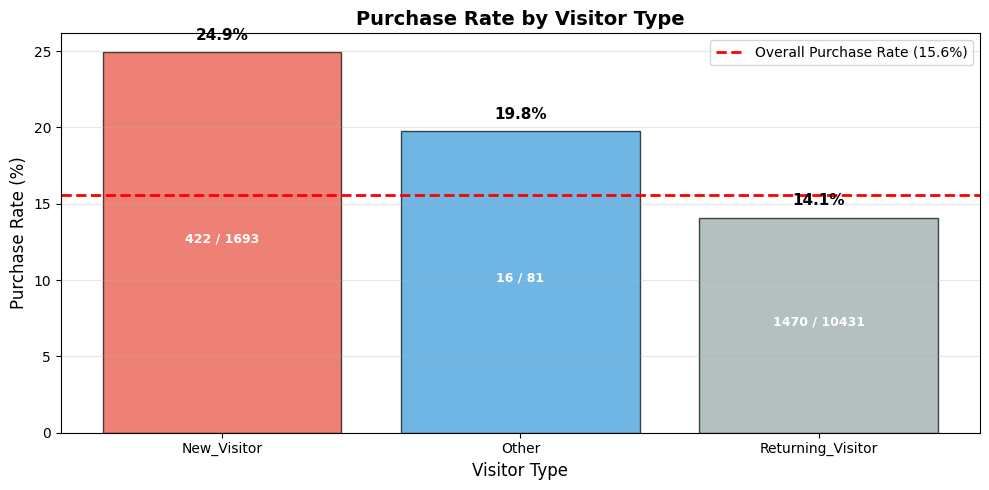

Purchase Rate by Visitor Type:

New_Visitor         : 24.93% ( 422 purchases /  1693 sessions)
Other               : 19.75% (  16 purchases /    81 sessions)
Returning_Visitor   : 14.09% (1470 purchases / 10431 sessions)


Returning visitors convert -10.83 percentage points lower than new visitors
Ratio: 0.57x


In [37]:
# calculate purchase rate by VisitorType
visitor_revenue = df_clean.groupby('VisitorType')['Revenue'].agg(['sum', 'count'])
visitor_revenue['purchase_rate'] = (visitor_revenue['sum'] / visitor_revenue['count']) * 100
visitor_revenue = visitor_revenue.sort_values('purchase_rate', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(visitor_revenue.index, visitor_revenue['purchase_rate'], 
               color=['#e74c3c', '#3498db', '#95a5a6'], edgecolor='black', alpha=0.7)
plt.title('Purchase Rate by Visitor Type', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Purchase Rate (%)', fontsize=12)
plt.axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)', linewidth=2)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# add value labels
for i, (idx, row) in enumerate(visitor_revenue.iterrows()):
    plt.text(i, row['purchase_rate'] + 0.8, f"{row['purchase_rate']:.1f}%", 
             ha='center', fontsize=11, fontweight='bold')
    plt.text(i, row['purchase_rate']/2, f"{int(row['sum'])} / {int(row['count'])}", 
             ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Visitor Type:\n")
for visitor_type in visitor_revenue.index:
    rate = visitor_revenue.loc[visitor_type, 'purchase_rate']
    count = visitor_revenue.loc[visitor_type, 'count']
    purchases = visitor_revenue.loc[visitor_type, 'sum']
    print(f"{visitor_type:20s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):5d} sessions)")

print("\n" + "="*70 + "\n")

# compare returning vs new (excluding "Other" due to small sample)
returning_rate = visitor_revenue.loc['Returning_Visitor', 'purchase_rate']
new_rate = visitor_revenue.loc['New_Visitor', 'purchase_rate']
print(f"Returning visitors convert {returning_rate - new_rate:.2f} percentage points {'higher' if returning_rate > new_rate else 'lower'} than new visitors")
print(f"Ratio: {returning_rate / new_rate:.2f}x")

**KEY FINDING:** Contrary to typical e-commerce assumptions, new visitors have a significantly HIGHER purchase rate (24.93%) than returning visitors (14.09%) - a 1.77x difference. This counter-intuitive result suggests several possibilities:

1. **Targeted acquisition**: New visitors may arrive through targeted marketing campaigns with specific purchase intent
2. **Research behavior**: Returning visitors might be comparison shopping or researching across multiple sessions before deciding
3. **Selection bias**: The dataset design (one session per user over 1 year) may capture new visitors at their moment of purchase, while returning visitors include many browse-only sessions
4. **Discount hunting**: Returning visitors might be waiting for promotions

The "Other" category shows 19.75% conversion but with only 81 sessions, making it less reliable. This finding highlights that VisitorType should be included in modeling, though its predictive direction differs from expectations. This also suggests we should examine the interaction between VisitorType and other features like PageValues.


**Summary of Bivariate Analysis:**

From our bivariate analysis, we have identified key predictors of purchase behavior:

**Strong Predictors (Large Effect):**

- **PageValues**: 13.6x higher mean for purchasers; 80.6% of purchases have non-zero PageValues
- **BounceRates**: 353% lower for purchasers; strong engagement indicator
- **ExitRates**: 133% lower for purchasers; confirms engagement importance

**Moderate Predictors (Medium Effect):**

- **ProductRelated features**: 66-73% higher for purchasers; more browsing = higher purchase likelihood
- **Month**: 1.7% to 25.5% range; November peak suggests strong seasonality effect
- **VisitorType**: Unexpected pattern with new visitors converting 1.77x better

**Weak Predictors (Small Effect):**

- **Weekend**: Small difference (17.5% vs 15.1%); weekend shoppers slightly more likely to purchase

These insights will directly inform our feature engineering and model building in the next phase.


#### **Correlation Analysis**

Correlation analysis helps us understand relationships between numerical features and identify potential multicollinearity issues. This is crucial for feature selection and model building.


**Correlation Heatmap**

We examine correlations between all numerical features to identify redundant features (high correlation indicates similar information) and understand feature relationships.


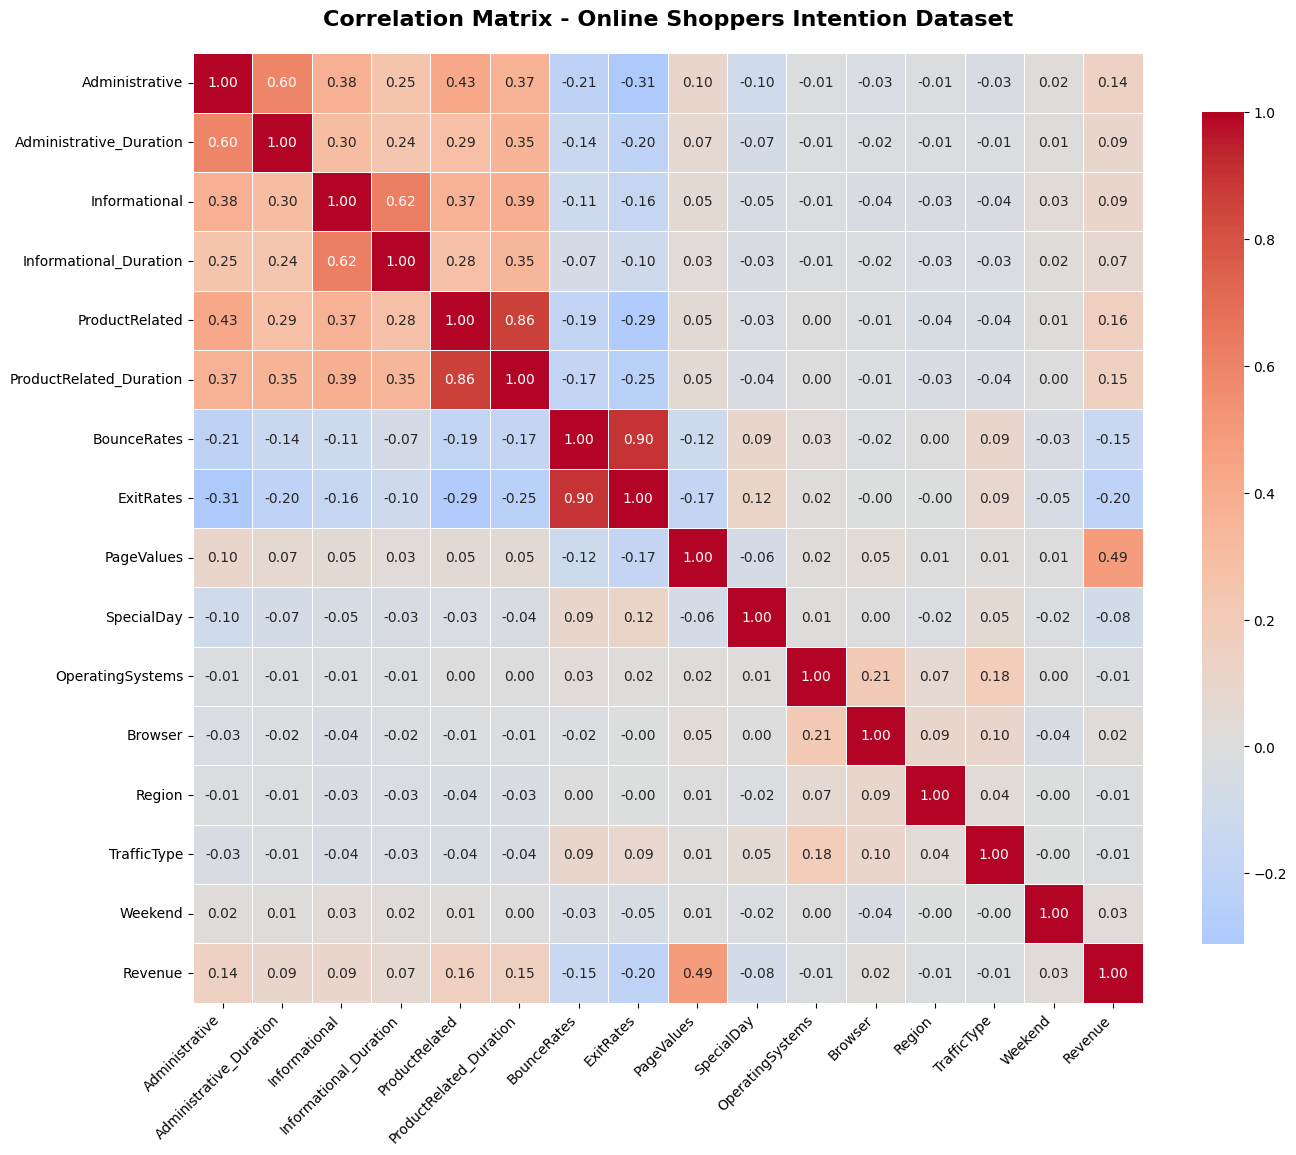

Highly Correlated Feature Pairs (|correlation| > 0.7):

ProductRelated                 <-> ProductRelated_Duration        :  0.860
BounceRates                    <-> ExitRates                      :  0.902


In [38]:
plt.figure(figsize=(14, 12))
correlation_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='coolwarm',  # Red (positive) to Blue (negative)
            center=0,    # Center colormap at 0
            square=True, # Square cells
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - Online Shoppers Intention Dataset', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# identify highly correlated pairs (threshold > 0.7)
print("Highly Correlated Feature Pairs (|correlation| > 0.7):\n")
print("="*70)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((feature1, feature2, corr_value))
            print(f"{feature1:30s} <-> {feature2:30s} : {corr_value:6.3f}")

if len(high_corr_pairs) == 0:
    print("No feature pairs with correlation > 0.7 found.")

**Key Correlation Insights:**

The heatmap reveals two important highly correlated pairs that indicate multicollinearity:

1. **ProductRelated & ProductRelated_Duration (0.86)**: Strong positive correlation indicates that users who visit more product pages naturally spend more time browsing. While both are predictive of purchases, they contain overlapping information.

2. **BounceRates & ExitRates (0.90)**: Very high correlation shows these metrics measure similar exit behavior. This is the strongest multicollinearity in our dataset and suggests we should consider keeping only one of these features in our final model.

**Positive Findings:**

- Most features show low to moderate correlations (< 0.7), indicating they provide unique information
- System features (OperatingSystems, Browser, Region, TrafficType) have very low correlations with other features, suggesting they capture independent user characteristics
- PageValues shows relatively low correlation with most features except Revenue, confirming it provides unique predictive value

**Implications for Modeling:**
To avoid multicollinearity issues, we may need to drop one feature from each highly correlated pair during feature selection. This will be addressed in the feature engineering phase.


**Feature Correlation with Target (Revenue)**

Now we examine which features have the strongest correlation with our target variable. This helps us rank features by their potential predictive power for classification.


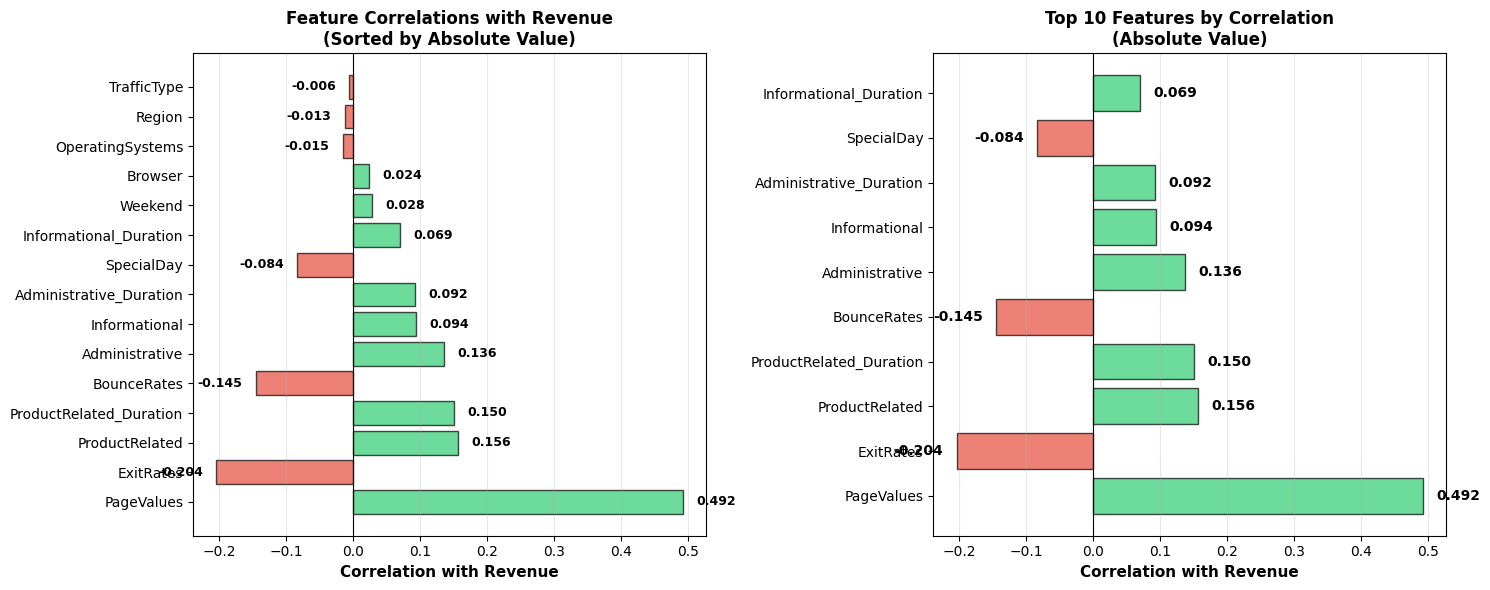

Feature Correlation with Revenue (Ranked by Absolute Value):

Rank   Feature                         Correlation Direction      
1      PageValues                           0.4919   Positive       
2      ExitRates                           -0.2043   Negative       
3      ProductRelated                       0.1560   Positive       
4      ProductRelated_Duration              0.1501   Positive       
5      BounceRates                         -0.1451   Negative       
6      Administrative                       0.1363   Positive       
7      Informational                        0.0936   Positive       
8      Administrative_Duration              0.0918   Positive       
9      SpecialDay                          -0.0836   Negative       
10     Informational_Duration               0.0694   Positive       
11     Weekend                              0.0277   Positive       
12     Browser                              0.0241   Positive       
13     OperatingSystems                    

In [39]:
# extract correlations with Revenue and sort by absolute value
revenue_correlations = correlation_matrix['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)

# create bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# plot 1: All correlations sorted by absolute value
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in revenue_correlations.values]
axes[0].barh(range(len(revenue_correlations)), revenue_correlations.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(revenue_correlations)))
axes[0].set_yticklabels(revenue_correlations.index)
axes[0].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Correlations with Revenue\n(Sorted by Absolute Value)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(revenue_correlations.values):
    axes[0].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=9, fontweight='bold')

# plot 2: Top 10 features only
top_10 = revenue_correlations.head(10)
colors_top10 = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_10.values]
axes[1].barh(range(len(top_10)), top_10.values, color=colors_top10, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_10)))
axes[1].set_yticklabels(top_10.index)
axes[1].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Features by Correlation\n(Absolute Value)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(top_10.values):
    axes[1].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed ranking
print("Feature Correlation with Revenue (Ranked by Absolute Value):\n")
print("="*70)
print(f"{'Rank':<6} {'Feature':<30} {'Correlation':>12} {'Direction':<15}")
print("="*70)

for rank, (feature, corr) in enumerate(revenue_correlations.items(), 1):
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{rank:<6} {feature:<30} {corr:>12.4f}   {direction:<15}")

print("\n" + "="*70)
print("\nInterpretation:")
print("- Positive correlation: Higher feature value → Higher purchase likelihood")
print("- Negative correlation: Higher feature value → Lower purchase likelihood")

**Feature Importance Ranking Analysis:**

The correlation analysis confirms our bivariate findings and provides clear feature importance ranking:

**Tier 1 - Strong Predictors (|correlation| > 0.15):**

- **PageValues (0.49)**: By far the strongest predictor. This validates our bivariate analysis where 80.6% of purchases had non-zero PageValues. This feature should be prioritized in all models.
- **ExitRates (-0.20)**: Negative correlation confirms that lower exit rates indicate higher purchase likelihood
- **ProductRelated features (0.15-0.16)**: Both page visits and duration show moderate positive correlation

**Tier 2 - Moderate Predictors (0.09 < |correlation| < 0.15):**

- **BounceRates (-0.15)**: Similar to ExitRates, lower bounce indicates better engagement
- **Administrative features (0.09-0.14)**: Weak but present positive relationship
- **Informational features (0.07-0.09)**: Very weak positive relationship

**Tier 3 - Weak/Negligible Predictors (|correlation| < 0.09):**

- **SpecialDay (-0.08)**: Slight negative correlation, contrary to expectations
- **System features** (Browser, OS, Region, TrafficType): All near-zero correlations (< 0.03), suggesting these don't directly predict purchases

**Critical Insights for Feature Engineering:**

1. Focus modeling efforts on Tier 1 features, especially PageValues
2. Resolve multicollinearity by selecting one feature from correlated pairs (ExitRates vs BounceRates, ProductRelated vs ProductRelated_Duration)
3. Consider dropping or transforming Tier 3 features with minimal predictive value
4. Categorical features (Month, VisitorType, Weekend) not shown here but proved important in bivariate analysis - these will be encoded and included


## **Task 2: Feature Engineering**


In [40]:
df_clean.groupby('Month').agg({
    'Revenue': 'mean',  # Purchase rate
    'PageValues': 'mean',  # Shopping intent
    'ProductRelated': 'mean'  # Product browsing
}).sort_values('Revenue', ascending=False)

,Revenue,PageValues,ProductRelated
Month,,,
Nov,0.254863,7.167632,46.280013
Oct,0.209472,8.645580,33.566485
Sep,0.191964,7.556826,33.104911
Aug,0.175520,5.938070,38.258661
Jul,0.152778,4.104414,36.407407
Dec,0.126612,6.917357,28.327081
May,0.109643,5.488680,26.755182
Mar,0.103226,4.059738,20.281720
June,0.101754,3.427139,36.435088


### **Feature Preprocessing**

Our preprocessing pipeline transforms the raw Online Shoppers dataset into 
a clustering-ready format through five systematic steps:

**Step 1: Target Variable Removal**
We removed the Revenue column to prevent data leakage, ensuring our 
unsupervised clustering analysis is not influenced by the classification 
target variable.

**Step 2: Behavioral Feature Engineering**
We created six new features to capture meaningful shopping patterns:
- *Total_Pages* and *Total_Duration* measure overall engagement intensity
- *Avg_Time_Per_Page* distinguishes quick browsers from careful researchers  
- *Product_Focus_Ratio* identifies shoppers focused on products versus 
  informational content
- *Engagement_Score* combines bounce rates, exit rates, and page values into 
  a single quality metric
- *Is_Peak_Season* flags holiday shopping periods (May, November, 
  December) when behavior differs from typical patterns

**Step 3: Temporal Feature Aggregation**
The original Month column was replaced by *Is_Peak_Season*, a binary 
indicator that captures the essential temporal pattern (peak vs. non-peak 
shopping periods) without creating sparse one-hot encoded features. This 
reduces dimensionality while preserving the key insight that customer 
behavior differs during holiday seasons.

**Step 4: Categorical Variable Encoding**
We applied one-hot encoding to VisitorType using sklearn's OneHotEncoder 
with drop='first' parameter. This converts categories into numerical format 
suitable for distance-based clustering algorithms while avoiding 
multicollinearity (dummy variable trap).

**Step 5: Feature Scaling**
We standardized all continuous numerical features using StandardScaler to 
ensure equal contribution to distance calculations. This transforms features 
to have mean=0 and standard deviation=1, making them comparable regardless 
of original scale. Binary features (Is_Peak_Season, Weekend, and one-hot 
encoded VisitorType) were preserved in their original scale as they are 
already comparable.

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def preprocess_for_clustering(df):
    """
    Preprocess Online Shoppers dataset for clustering analysis.
    
    Args:
        df: Original dataframe with all columns
        
    Returns:
        df_processed: DataFrame ready for clustering
        feature_names: List of final feature names
    """
    df_processed = df.copy()
    
    # Remove target variable
    if 'Revenue' in df_processed.columns:
        df_processed = df_processed.drop('Revenue', axis=1)
    
    # Create behavioral features
    df_processed['Total_Pages'] = (
        df_processed['Administrative'] + 
        df_processed['Informational'] + 
        df_processed['ProductRelated']
    )
    
    df_processed['Total_Duration'] = (
        df_processed['Administrative_Duration'] + 
        df_processed['Informational_Duration'] + 
        df_processed['ProductRelated_Duration']
    )
    
    df_processed['Avg_Time_Per_Page'] = df_processed['Total_Duration'] / (df_processed['Total_Pages'] + 1)
    df_processed['Product_Focus_Ratio'] = df_processed['ProductRelated'] / (df_processed['Total_Pages'] + 1)
    
    df_processed['Engagement_Score'] = (
        (1 - df_processed['BounceRates']) * 
        (1 - df_processed['ExitRates']) * 
        df_processed['PageValues']
    )
    
    # Create temporal features
    peak_months = ['May', 'Nov', 'Dec']
    df_processed['Is_Peak_Season'] = df_processed['Month'].isin(peak_months).astype(int)
    
    # Convert Weekend to integer
    if df_processed['Weekend'].dtype == 'bool':
        df_processed['Weekend'] = df_processed['Weekend'].astype(int)
    
    # One-hot encode VisitorType (Month dropped - replaced by Is_Peak_Season)
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    categorical_cols = ['VisitorType']
    encoded_array = encoder.fit_transform(df_processed[categorical_cols])
    encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df_processed.index)
    
    # Drop original categorical columns
    df_processed = df_processed.drop(['Month', 'VisitorType'], axis=1)
    df_processed = pd.concat([df_processed, encoded_df], axis=1)
    
    # Standardize numerical features (exclude binary columns)
    numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
    binary_cols = [col for col in numerical_cols if df_processed[col].nunique() == 2]
    cols_to_standardize = [col for col in numerical_cols if col not in binary_cols]
    
    scaler = StandardScaler()
    df_processed[cols_to_standardize] = scaler.fit_transform(df_processed[cols_to_standardize])
    
    feature_names = df_processed.columns.tolist()
    
    # Summary Report
    n_engineered = 6
    n_original_numerical = len(numerical_cols) - n_engineered - len(binary_cols)
    
    print("\n" + "="*70)
    print("📊 PREPROCESSING SUMMARY")
    print("="*70)
    print(f"\n✅ Dataset Shape: {df.shape} → {df_processed.shape}")
    print(f"   Rows: {df.shape[0]:,} (unchanged)")
    print(f"   Columns: {df.shape[1]} → {df_processed.shape[1]}")
    
    print(f"\n📝 Transformations Applied:")
    print(f"   • Removed: Revenue (target variable), Month (replaced by Is_Peak_Season)")
    print(f"   • Created: 6 engineered features")
    print(f"      - Total_Pages, Total_Duration, Avg_Time_Per_Page")
    print(f"      - Product_Focus_Ratio, Engagement_Score, Is_Peak_Season")
    print(f"   • Encoded: VisitorType → one-hot encoding (drop first)")
    print(f"   • Scaled: {len(cols_to_standardize)} numerical features (StandardScaler)")
    print(f"   • Binary: {len(binary_cols)} features kept unchanged")
    
    print(f"\n🔢 Final Feature Composition:")
    print(f"   Original numerical: {n_original_numerical}")
    print(f"   Engineered features: {n_engineered}")
    print(f"   One-hot encoded: {len(encoded_feature_names)}")
    print(f"   Binary features: {len(binary_cols)}")
    print(f"   ─────────────────────────")
    print(f"   Total features: {len(feature_names)}")
    
    print("\n" + "="*70 + "\n")
    
    return df_processed, feature_names

In [42]:
# Preprocess for clustering
df_clustered, features = preprocess_for_clustering(df)

# Now df_clustered is ready for clustering algorithms
print(df_clustered.describe().T)
print(f"Features: {features}")


📊 PREPROCESSING SUMMARY

✅ Dataset Shape: (12330, 18) → (12330, 23)
   Rows: 12,330 (unchanged)
   Columns: 18 → 23

📝 Transformations Applied:
   • Removed: Revenue (target variable), Month (replaced by Is_Peak_Season)
   • Created: 6 engineered features
      - Total_Pages, Total_Duration, Avg_Time_Per_Page
      - Product_Focus_Ratio, Engagement_Score, Is_Peak_Season
   • Encoded: VisitorType → one-hot encoding (drop first)
   • Scaled: 19 numerical features (StandardScaler)
   • Binary: 4 features kept unchanged

🔢 Final Feature Composition:
   Original numerical: 13
   Engineered features: 6
   One-hot encoded: 2
   Binary features: 4
   ─────────────────────────
   Total features: 23


                                 count          mean       std       min  \
Administrative                 12330.0 -2.766103e-17  1.000041 -0.696993   
Administrative_Duration        12330.0  5.993223e-17  1.000041 -0.457191   
Informational                  12330.0 -2.305086e-17  1.000041 -0.3964

**Result**
This preprocessing pipeline increased our feature count from 18 original 
columns to 32 engineered features, providing the clustering algorithm with 
rich, normalized behavioral signals that capture browsing patterns and 
temporal shopping dynamics.

### **Feature Selection**

#### **Clustering**

##### **Why These Methods Were Selected**

We selected Laplacian Score and Multi-Cluster Feature Selection (MCFS) as our two 
feature selection methods because they work in different but complementary ways. 
Laplacian Score looks at how well features preserve the "neighborhood" structure 
of our data—essentially, it identifies features where similar customers remain 
similar. It builds a graph connecting each customer to their nearest neighbors 
(we tested k values of 3, 5, 7, and 10) using heat kernel 
weighting (t=1.0), then scores features based on how smoothly they vary across 
these connections. Features with low scores are better because they maintain 
natural groupings in customer behavior without creating artificial gaps between 
similar visitors. MCFS takes a different approach by explicitly trying to separate 
multiple customer segments. It uses spectral analysis to find features that best 
distinguish between different groups (we tested 3, 4, and 5 clusters), solving optimization problems to select features that maximize the 
differences between segments while keeping the selection sparse and interpretable.

The reason I chose both methods is that they capture different aspects of what 
makes a good feature for clustering. Laplacian Score focuses on local patterns—
making sure customers who browse similarly stay grouped together regardless of 
which segment they belong to. MCFS focuses on global separation—finding features 
that clearly distinguish one customer type from another. By using both, I ensure 
the selected features both preserve fine-grained behavioral similarities and create 
clear boundaries between distinct customer personas. Importantly, both methods are 
completely unsupervised, meaning they don't need any pre-labeled customer categories. 
This aligns perfectly with our business goal of discovering natural customer segments 
rather than forcing data into predefined boxes.

##### ***Laplacian Score***

In [50]:
# laplacian_score_skfeature.py

import pandas as pd
import numpy as np
from skfeature.utility import construct_W
from skfeature.function.similarity_based import lap_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

def apply_laplacian_score(df_clustered, n_features_list=[10, 12, 15], k_list=[3, 5, 7, 10], n_clusters=4):
    """
    Apply Laplacian Score with automatic optimization using scikit-feature library.
    
    Args:
        df_clustered: Preprocessed & SCALED DataFrame for clustering
        n_features_list: List of n_features to test (default: [10, 12, 15])
        k_list: List of k values to test (default: [3, 5, 7, 10])
        n_clusters: Number of clusters for evaluation (default: 4)
    
    Returns:
        df_selected: DataFrame with selected features only
        selected_features: List of selected feature names
        best_n_features: Optimal number of features
        best_k: Optimal k value
        results_df: DataFrame with optimization results
    """
    results = []
    X = df_clustered.values
    feature_names = df_clustered.columns
    
    total = len(n_features_list) * len(k_list)
    print(f"Testing {total} combinations (n_features × k)...")
    print(f"  (metric=euclidean, weight_mode=heat_kernel, t=1.0)")
    print(f"{'='*60}")
    
    # Test all combinations
    for n_feat in n_features_list:
        for k in k_list:
            try:
                # Construct affinity matrix W with explicit parameters
                kwargs_W = {
                    "metric": "euclidean",
                    "neighbor_mode": "knn",
                    "weight_mode": "heat_kernel",
                    "k": k,
                    "t": 1.0
                }
                W = construct_W.construct_W(X, **kwargs_W)
                
                # Compute Laplacian scores using skfeature
                lap_scores = lap_score.lap_score(X, W=W)
                
                # Rank features (lower score = better)
                idx = np.argsort(lap_scores)
                
                # Select top n features
                selected_indices = idx[:n_feat]
                X_selected = X[:, selected_indices]
                
                # Evaluate with K-Means
                kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
                labels = kmeans.fit_predict(X_selected)
                
                sil_score = silhouette_score(X_selected, labels)
                db_score = davies_bouldin_score(X_selected, labels)
                
                results.append({
                    'n_features': n_feat,
                    'k': k,
                    'silhouette': sil_score,
                    'davies_bouldin': db_score,
                    'feature_indices': idx
                })
                
                print(f"n_features={n_feat:2d}, k={k:2d} | Sil={sil_score:.4f} | DB={db_score:.4f}")
                
            except Exception as e:
                print(f"⚠️  Failed for n_features={n_feat}, k={k}: {e}")
                continue
    
    results_df = pd.DataFrame(results)
    
    # Find best combination
    best_idx = results_df['silhouette'].idxmax()
    best_n_features = int(results_df.loc[best_idx, 'n_features'])
    best_k = int(results_df.loc[best_idx, 'k'])
    best_indices = results_df.loc[best_idx, 'feature_indices']
    
    print(f"\n{'='*60}")
    print(f"✅ BEST PARAMETERS:")
    print(f"   n_features: {best_n_features}")
    print(f"   k: {best_k}")
    print(f"   Silhouette: {results_df.loc[best_idx, 'silhouette']:.4f}")
    print(f"   Davies-Bouldin: {results_df.loc[best_idx, 'davies_bouldin']:.4f}")
    
    # Select features with best parameters
    selected_features = feature_names[best_indices[:best_n_features]].tolist()
    df_selected = df_clustered[selected_features]
    
    print(f"\n📋 SELECTED FEATURES (Top {best_n_features}):")
    for i, feat in enumerate(selected_features, 1):
        print(f"   {i:2d}. {feat}")
    print(f"{'='*60}\n")
    
    return df_selected, selected_features, best_n_features, best_k, results_df


def plot_laplacian_results(results_df, best_n_features, best_k):
    """
    Visualize Laplacian Score optimization results.
    
    Args:
        results_df: DataFrame from apply_laplacian_score()
        best_n_features: Optimal number of features
        best_k: Optimal k value
    """
    # Create separate plots for each n_features value
    unique_n_features = sorted(results_df['n_features'].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Silhouette Score
    for n_feat in unique_n_features:
        subset = results_df[results_df['n_features'] == n_feat]
        axes[0].plot(subset['k'], subset['silhouette'], 
                     'o-', linewidth=2, markersize=8, label=f'n_features={n_feat}')
    
    axes[0].set_xlabel('k (neighbors)', fontsize=11)
    axes[0].set_ylabel('Silhouette Score', fontsize=11)
    axes[0].set_title('Silhouette Score vs k\n(Higher is Better)', 
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[0].axvline(best_k, color='red', linestyle='--', alpha=0.3)
    
    # Plot 2: Davies-Bouldin Index
    for n_feat in unique_n_features:
        subset = results_df[results_df['n_features'] == n_feat]
        axes[1].plot(subset['k'], subset['davies_bouldin'], 
                     'o-', linewidth=2, markersize=8, label=f'n_features={n_feat}')
    
    axes[1].set_xlabel('k (neighbors)', fontsize=11)
    axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
    axes[1].set_title('Davies-Bouldin Index vs k\n(Lower is Better)', 
                      fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].axvline(best_k, color='red', linestyle='--', alpha=0.3)
    
    plt.suptitle(f'Best: n_features={best_n_features}, k={best_k}', 
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

Testing 12 combinations (n_features × k)...
  (metric=euclidean, weight_mode=heat_kernel, t=1.0)
n_features=10, k= 3 | Sil=0.2739 | DB=1.2660
n_features=10, k= 5 | Sil=0.2995 | DB=1.1339
n_features=10, k= 7 | Sil=0.2669 | DB=1.4466
n_features=10, k=10 | Sil=0.3025 | DB=1.1979
n_features=12, k= 3 | Sil=0.3060 | DB=1.2366
n_features=12, k= 5 | Sil=0.3581 | DB=1.3573
n_features=12, k= 7 | Sil=0.2211 | DB=1.5747
n_features=12, k=10 | Sil=0.2309 | DB=1.3961
n_features=15, k= 3 | Sil=0.3936 | DB=1.2309
n_features=15, k= 5 | Sil=0.3985 | DB=1.2395
n_features=15, k= 7 | Sil=0.2930 | DB=1.3553
n_features=15, k=10 | Sil=0.3844 | DB=1.2924

✅ BEST PARAMETERS:
   n_features: 15
   k: 5
   Silhouette: 0.3985
   Davies-Bouldin: 1.2395

📋 SELECTED FEATURES (Top 15):
    1. Is_Peak_Season
    2. VisitorType_Other
    3. Engagement_Score
    4. Informational
    5. Region
    6. Product_Focus_Ratio
    7. BounceRates
    8. PageValues
    9. VisitorType_Returning_Visitor
   10. Weekend
   11. Avg_Time_

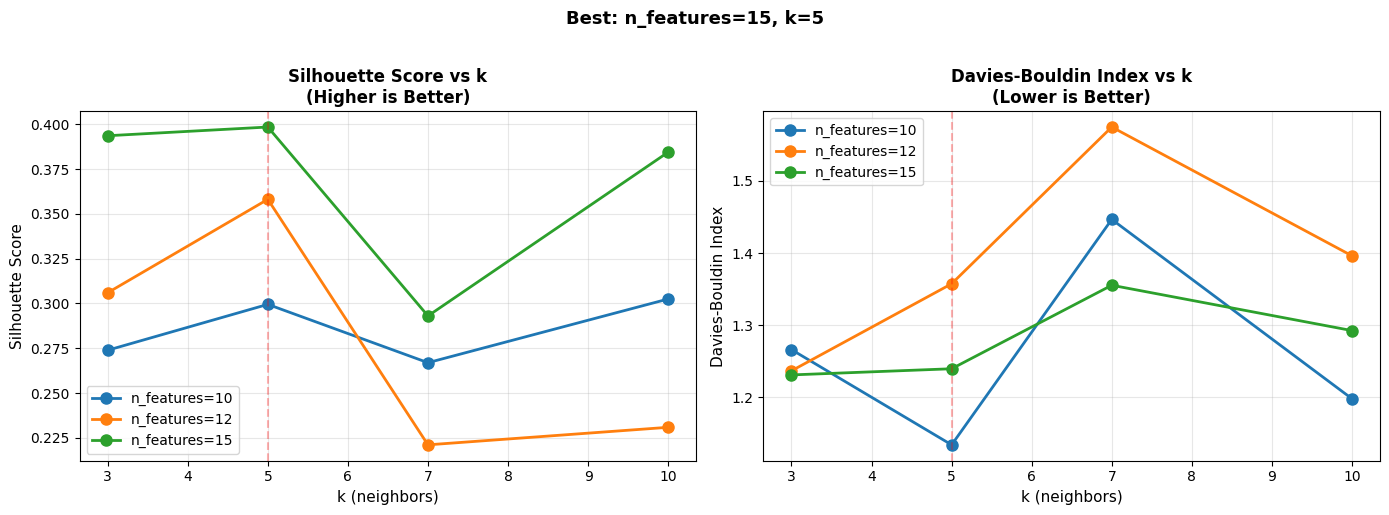

In [51]:
# Apply Laplacian Score (uses skfeature library)
df_lap, features_lap, best_n, best_k, results = apply_laplacian_score(
    df_clustered,
    n_features_list=[10, 12, 15],
    k_list=[3, 5, 7, 10]
)

# Plot results
plot_laplacian_results(results, best_n, best_k)

**Key Findings and Results**

For Laplacian Score, I tested 12 different parameter combinations by varying the 
number of features to select (10, 12, or 15) and the number of neighbors (k = 3, 
5, 7, or 10). The best configuration was 15 features with k=5 neighbors, achieving 
a Silhouette score of 0.3985 (higher is better) and Davies-Bouldin index of 1.2395 
(lower is better). The top-ranked features reveal interesting patterns: Is_Peak_Season 
ranked first, showing that shopping timing is critical for understanding customer 
behavior. Visitor characteristics like VisitorType_Other and VisitorType_Returning_Visitor 
appeared in the top 5, while engagement metrics such as Engagement_Score, BounceRates, 
and PageValues also ranked highly. I was particularly pleased to see that my engineered 
features—Product_Focus_Ratio and Avg_Time_Per_Page—made it into the top 15, validating 
that these custom metrics capture meaningful behavioral patterns. The fact that 15 
features performed significantly better than 10 or 12 tells me that customer behavior 
is complex enough to require this level of dimensionality, and k=5 suggests that 
looking at approximately 5 similar customers provides the right balance for preserving 
local behavioral patterns.

##### ***Multi-Cluster Feature Selection***

In [52]:
# mcfs_skfeature.py

import pandas as pd
import numpy as np
from skfeature.utility import construct_W
from skfeature.function.sparse_learning_based import MCFS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

def apply_mcfs(df_clustered, n_features=15, mcfs_n_clusters_list=[3, 4, 5], eval_n_clusters=4):
    """
    Apply MCFS feature selection with automatic n_clusters optimization using skfeature.
    
    Args:
        df_clustered: Preprocessed & SCALED DataFrame for clustering
        n_features: Number of features to select (default: 15)
        mcfs_n_clusters_list: List of MCFS n_clusters to test (default: [3, 4, 5])
        eval_n_clusters: Number of clusters for evaluation (default: 4)
    
    Returns:
        df_selected: DataFrame with selected features only
        selected_features: List of selected feature names
        best_mcfs_clusters: Optimal MCFS n_clusters value
        results_df: DataFrame with optimization results
    """
    results = []
    X = df_clustered.values
    feature_names = df_clustered.columns
    
    print(f"Testing {len(mcfs_n_clusters_list)} MCFS n_clusters values...")
    print(f"  (n_features fixed at {n_features})")
    print(f"{'='*60}")
    
    # Step 1: Find best mcfs_n_clusters
    for mcfs_clusters in mcfs_n_clusters_list:
        try:
            # Construct affinity matrix W (optional but recommended)
            kwargs_W = {
                "metric": "euclidean",
                "neighbor_mode": "knn",
                "k": 5,
                "t": 1.0
            }
            W = construct_W.construct_W(X, **kwargs_W)
            
            # Apply MCFS with explicit W
            weight = MCFS.mcfs(X, n_selected_features=n_features, W=W, n_clusters=mcfs_clusters)
            
            # Compute feature scores
            if weight.ndim == 1:
                scores = np.abs(weight)
            else:
                # Use max across clusters (as in skfeature)
                scores = np.max(np.abs(weight), axis=1)
            
            # Rank and select top features
            idx = np.argsort(scores)[::-1]  # Descending order
            top_indices = idx[:n_features]
            X_selected = X[:, top_indices]
            
            # Evaluate with K-Means
            kmeans = KMeans(n_clusters=eval_n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_selected)
            
            sil_score = silhouette_score(X_selected, labels)
            db_score = davies_bouldin_score(X_selected, labels)
            
            results.append({
                'mcfs_n_clusters': mcfs_clusters,
                'silhouette': sil_score,
                'davies_bouldin': db_score,
                'top_indices': top_indices
            })
            
            print(f"mcfs_clusters={mcfs_clusters} | Sil={sil_score:.4f} | DB={db_score:.4f}")
            
        except Exception as e:
            print(f"⚠️  Failed for mcfs_clusters={mcfs_clusters}: {e}")
            continue
    
    results_df = pd.DataFrame(results)
    
    # Find best mcfs_n_clusters
    best_idx = results_df['silhouette'].idxmax()
    best_mcfs_clusters = int(results_df.loc[best_idx, 'mcfs_n_clusters'])
    best_indices = results_df.loc[best_idx, 'top_indices']
    
    print(f"\n{'='*60}")
    print(f"✅ BEST PARAMETERS:")
    print(f"   n_features: {n_features} (fixed)")
    print(f"   mcfs_n_clusters: {best_mcfs_clusters}")
    print(f"   Silhouette Score: {results_df.loc[best_idx, 'silhouette']:.4f}")
    print(f"   Davies-Bouldin: {results_df.loc[best_idx, 'davies_bouldin']:.4f}")
    
    # Step 2: Apply with best parameters
    selected_features = feature_names[best_indices].tolist()
    df_selected = df_clustered[selected_features]
    
    print(f"\n📋 SELECTED FEATURES (Top {n_features}):")
    for i, feat in enumerate(selected_features, 1):
        print(f"   {i:2d}. {feat}")
    print(f"{'='*60}\n")
    
    return df_selected, selected_features, best_mcfs_clusters, results_df


def plot_mcfs_results(results_df, best_mcfs_clusters):
    """
    Visualize MCFS n_clusters optimization results.
    
    Args:
        results_df: DataFrame from apply_mcfs()
        best_mcfs_clusters: Optimal MCFS n_clusters value
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Silhouette Score
    axes[0].plot(results_df['mcfs_n_clusters'], results_df['silhouette'], 
                 'o-', color='#2E86AB', linewidth=2, markersize=10)
    axes[0].set_xlabel('MCFS n_clusters', fontsize=11)
    axes[0].set_ylabel('Silhouette Score', fontsize=11)
    axes[0].set_title('Silhouette Score vs MCFS n_clusters\n(Higher is Better)', 
                      fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(best_mcfs_clusters, color='red', linestyle='--', 
                    alpha=0.5, label=f'Best={best_mcfs_clusters}')
    axes[0].legend()
    
    # Plot 2: Davies-Bouldin Index
    axes[1].plot(results_df['mcfs_n_clusters'], results_df['davies_bouldin'], 
                 'o-', color='#A23B72', linewidth=2, markersize=10)
    axes[1].set_xlabel('MCFS n_clusters', fontsize=11)
    axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
    axes[1].set_title('Davies-Bouldin Index vs MCFS n_clusters\n(Lower is Better)', 
                      fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(best_mcfs_clusters, color='red', linestyle='--', 
                    alpha=0.5, label=f'Best={best_mcfs_clusters}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

Testing 3 MCFS n_clusters values...
  (n_features fixed at 15)
mcfs_clusters=3 | Sil=0.3709 | DB=1.2670
mcfs_clusters=4 | Sil=0.2518 | DB=1.6107
mcfs_clusters=5 | Sil=0.2353 | DB=1.5447

✅ BEST PARAMETERS:
   n_features: 15 (fixed)
   mcfs_n_clusters: 3
   Silhouette Score: 0.3709
   Davies-Bouldin: 1.2670

📋 SELECTED FEATURES (Top 15):
    1. TrafficType
    2. VisitorType_Returning_Visitor
    3. Total_Duration
    4. Total_Pages
    5. VisitorType_Other
    6. Is_Peak_Season
    7. Informational
    8. ExitRates
    9. Engagement_Score
   10. Browser
   11. Informational_Duration
   12. PageValues
   13. Region
   14. SpecialDay
   15. BounceRates



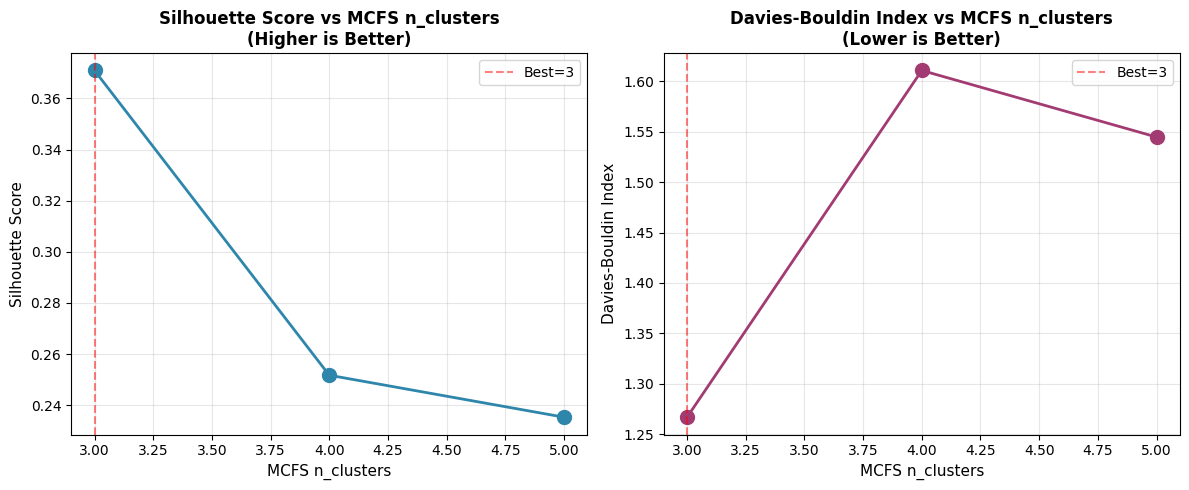

In [53]:
# Apply MCFS (uses skfeature library with explicit W construction)
df_mcfs, features_mcfs, best_clusters, results = apply_mcfs(
    df_clustered,
    n_features=15,
    mcfs_n_clusters_list=[3, 4, 5]
)

# Plot results
plot_mcfs_results(results, best_clusters)

**Key Findings and Results**

MCFS optimization tested whether 3, 4, or 5 internal clusters work best for feature 
selection, keeping the number of selected features fixed at 15. The optimal configuration 
used 3 clusters, achieving a Silhouette score of 0.3709 and Davies-Bouldin index of 
1.2670. Interestingly, MCFS ranked features quite differently from Laplacian Score: 
TrafficType jumped to the top position, and Total_Duration ranked third, while 
Engagement_Score dropped to ninth place. This difference makes sense when I consider 
what each method optimizes for—MCFS prioritizes features that create clear separation 
between broad customer groups (like traffic source determining if someone came from 
ads versus organic search), while Laplacian Score emphasizes features that maintain 
consistency within local neighborhoods (like engagement patterns among similar browsers). 
The really valuable insight comes from looking at the overlap: 10 features appear 
in both top-15 lists (including VisitorType_Returning_Visitor, Is_Peak_Season, 
Engagement_Score, PageValues, BounceRates, and ExitRates). These overlapping features 
represent high-confidence selections—features that both preserve local behavioral 
structure AND separate global customer segments. These 10 features form my core 
feature set for the final clustering analysis, as they've been validated by two 
independent methods with different optimization objectives.

##### **Decision for selected feature**

Based on the results, I will test three feature sets to determine 
which provides the best clustering performance:

1. **Laplacian Score Features (15 features)** - Optimized for preserving local 
   neighborhood structure with the highest Silhouette score (0.3985)

2. **MCFS Features (15 features)** - Optimized for separating multiple customer 
   segments with strong cluster distinction (Silhouette: 0.3709)

3. **Overlap Features (10 features)** - High-confidence features validated by 
   both methods, representing the most robust subset for clustering

Each feature set will be evaluated across multiple clustering algorithms (K-Means, 
DBSCAN, Agglomerative Clustering) to determine which combination yields the most 
interpretable and well-separated customer segments. The final feature set will be 
selected based on both quantitative metrics (Silhouette, Davies-Bouldin) and 
qualitative assessment of business interpretability.

In [59]:
# Create the three feature sets for testing

# Feature lists from your results
laplacian_features = [
    'Is_Peak_Season', 'VisitorType_Other', 'Engagement_Score', 
    'Informational', 'Region', 'Product_Focus_Ratio', 
    'BounceRates', 'PageValues', 'VisitorType_Returning_Visitor',
    'Weekend', 'Avg_Time_Per_Page', 'ProductRelated_Duration', 
    'ExitRates', 'Administrative', 'Informational_Duration'
]

mcfs_features = [
    'TrafficType', 'VisitorType_Returning_Visitor', 'Total_Duration', 
    'Total_Pages', 'VisitorType_Other', 'Is_Peak_Season', 
    'Informational', 'ExitRates', 'Engagement_Score',
    'Browser', 'Informational_Duration', 'PageValues', 
    'Region', 'SpecialDay', 'BounceRates'
]

# Combine overlapfeatures in both lists)
combined_features = list(set(laplacian_features) & set(mcfs_features))

# Create the three datasets
df_laplacian = df_clustered[laplacian_features]
df_mcfs = df_clustered[mcfs_features]
df_combined = df_clustered[combined_features]

# Save to CSV files
# df_laplacian.to_csv(f'data/laplacian_features.csv', index=False)
# df_mcfs.to_csv(f'data/mcfs_features.csv', index=False)
# df_combined.to_csv(f'data/combined_features.csv', index=False)

# Verify
print(f"✅ Created 3 feature sets:")
print(f"   Laplacian: {len(laplacian_features)} features")
print(f"   MCFS: {len(mcfs_features)} features")
print(f"   Combined: {len(combined_features)} features")

print(f"\n📋 Laplacian features:")
for i, feat in enumerate(laplacian_features, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n📋 MCFS features:")
for i, feat in enumerate(mcfs_features, 1):
    print(f"   {i:2d}. {feat}")
print(f"\n📋 Combined features:")
for i, feat in enumerate(combined_features, 1):
    print(f"   {i:2d}. {feat}")

✅ Created 3 feature sets:
   Laplacian: 15 features
   MCFS: 15 features
   Combined: 10 features

📋 Laplacian features:
    1. Is_Peak_Season
    2. VisitorType_Other
    3. Engagement_Score
    4. Informational
    5. Region
    6. Product_Focus_Ratio
    7. BounceRates
    8. PageValues
    9. VisitorType_Returning_Visitor
   10. Weekend
   11. Avg_Time_Per_Page
   12. ProductRelated_Duration
   13. ExitRates
   14. Administrative
   15. Informational_Duration

📋 MCFS features:
    1. TrafficType
    2. VisitorType_Returning_Visitor
    3. Total_Duration
    4. Total_Pages
    5. VisitorType_Other
    6. Is_Peak_Season
    7. Informational
    8. ExitRates
    9. Engagement_Score
   10. Browser
   11. Informational_Duration
   12. PageValues
   13. Region
   14. SpecialDay
   15. BounceRates

📋 Combined features:
    1. Informational
    2. Engagement_Score
    3. VisitorType_Returning_Visitor
    4. VisitorType_Other
    5. Is_Peak_Season
    6. Region
    7. ExitRates
    8. Bounc

## **Task 3: Data Modelling**


### **Clustering**

In [64]:
df_laplacian = pd.read_csv('data/laplacian_features.csv')
df_mcfs = pd.read_csv('data/mcfs_features.csv')
df_combined = pd.read_csv('data/combined_features.csv')

feature_sets = {
    'Laplacian': df_laplacian,
    'MCFS': df_mcfs,
    'Combined': df_combined
}

#### K-Means

In [98]:
def kmeans(df_features, n_clusters_list=[3, 4, 5, 6], feature_set_name="Features"):
    """
    Optimize K-Means clustering by testing different n_clusters.
    
    Args:
        df_features: DataFrame with selected features
        n_clusters_list: List of n_clusters to test
        feature_set_name: Name of feature set for display
    
    Returns:
        best_model: Best trained K-Means model
        best_labels: Cluster labels from best model
        best_n_clusters: Optimal number of clusters
        results_df: DataFrame with all results
    """
    results = []
    X = df_features.values
    
    print(f"\nK-MEANS | {feature_set_name}")
    print(f"Testing {len(n_clusters_list)} configurations: k-means++, n_init=10, max_iter=300\n")
    
    for n_clusters in n_clusters_list:
        # Train K-Means
        kmeans = KMeans(
            n_clusters=n_clusters, 
            init='k-means++',
            n_init=10,
            max_iter=300,
            random_state=42
        )
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        sil_score = silhouette_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        
        results.append({
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'labels': labels,
            'model': kmeans
        })
        
        print(f"  k={n_clusters}  →  Silhouette Score: {sil_score:.4f}  |  Davies-Bouldin Index: {db_score:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find best based on Silhouette score
    best_idx = results_df['silhouette'].idxmax()
    best_n_clusters = int(results_df.loc[best_idx, 'n_clusters'])
    best_model = results_df.loc[best_idx, 'model']
    best_labels = results_df.loc[best_idx, 'labels']
    
    print(f"\nBEST: k={best_n_clusters}  |  Silhouette Score: {results_df.loc[best_idx, 'silhouette']:.4f}  |  Davies-Bouldin Index: {results_df.loc[best_idx, 'davies_bouldin']:.4f}\n")
    
    return best_model, best_labels, best_n_clusters, results_df

In [99]:
for name, df_feat in feature_sets.items():
    print(f"\n{'═'*70}")
    print(f"  {name.upper()} FEATURES")
    print(f"{'═'*70}")
    
    km_model, km_labels, km_n, km_results = kmeans(df_feat, feature_set_name=name)


══════════════════════════════════════════════════════════════════════
  LAPLACIAN FEATURES
══════════════════════════════════════════════════════════════════════

K-MEANS | Laplacian
Testing 4 configurations: k-means++, n_init=10, max_iter=300

  k=3  →  Silhouette Score: 0.3761  |  Davies-Bouldin Index: 1.5962
  k=4  →  Silhouette Score: 0.3985  |  Davies-Bouldin Index: 1.2395
  k=5  →  Silhouette Score: 0.2313  |  Davies-Bouldin Index: 1.4971
  k=6  →  Silhouette Score: 0.2191  |  Davies-Bouldin Index: 1.4327

BEST: k=4  |  Silhouette Score: 0.3985  |  Davies-Bouldin Index: 1.2395


══════════════════════════════════════════════════════════════════════
  MCFS FEATURES
══════════════════════════════════════════════════════════════════════

K-MEANS | MCFS
Testing 4 configurations: k-means++, n_init=10, max_iter=300

  k=3  →  Silhouette Score: 0.3546  |  Davies-Bouldin Index: 1.4078
  k=4  →  Silhouette Score: 0.3709  |  Davies-Bouldin Index: 1.2670
  k=5  →  Silhouette Score: 0.3346

#### DBSCAN

In [94]:
def dbscan(df_features, eps_list=[0.3, 0.5, 0.8, 1.2, 1.8, 2.5], 
           min_samples_list=[5, 10, 20,30], feature_set_name="Features"):
    """
    Optimize DBSCAN clustering by testing different eps and min_samples.

    Args:
        df_features: DataFrame with selected features
        eps_list: List of eps values to test
        min_samples_list: List of min_samples values to test
        feature_set_name: Name of feature set for display
    
    Returns:
        best_model: Best trained DBSCAN model
        best_labels: Cluster labels from best model
        best_eps: Optimal eps value
        best_min_samples: Optimal min_samples value
        results_df: DataFrame with all results
    """
    results = []
    X = df_features.values
    
    total_combinations = len(eps_list) * len(min_samples_list)
    
    print(f"\nDBSCAN | {feature_set_name}")
    print(f"Testing {total_combinations} parameter combinations (metric='euclidean')\n")
    
    for eps in eps_list:
        for min_samples in min_samples_list:
            # Train DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
            labels = dbscan.fit_predict(X)
            
            # Check clustering validity
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)
            noise_pct = (n_noise / len(labels)) * 100
            
            result = {
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'noise_pct': noise_pct,
                'silhouette': None,
                'davies_bouldin': None,
                'labels': labels,
                'model': dbscan,
                'valid': False
            }
            
            # Calculate metrics only for valid clustering
            if n_clusters >= 2 and n_noise < len(labels) * 0.5:
                mask = labels != -1
                if mask.sum() > 0:
                    sil_score = silhouette_score(X[mask], labels[mask])
                    db_score = davies_bouldin_score(X[mask], labels[mask])
                    result['silhouette'] = sil_score
                    result['davies_bouldin'] = db_score
                    result['valid'] = True
                    
                    print(f"  eps={eps:.1f}, min={min_samples:2d}  →  Clusters={n_clusters}, Noise={n_noise:4d} ({noise_pct:4.1f}%)  |  Silhouette: {sil_score:.4f}, Davies-Bouldin: {db_score:.4f}")
                else:
                    print(f"  eps={eps:.1f}, min={min_samples:2d}  →  ❌ All noise")
            else:
                print(f"  eps={eps:.1f}, min={min_samples:2d}  →  ❌ Invalid (Clusters={n_clusters}, Noise={noise_pct:.1f}%)")
            
            results.append(result)
    
    results_df = pd.DataFrame(results)
    valid_results = results_df[results_df['valid'] == True]
    
    if len(valid_results) == 0:
        print(f"\n⚠️  No valid DBSCAN clustering found\n")
        return None, None, None, None, results_df
    
    # Find best based on Silhouette score
    best_idx = valid_results['silhouette'].idxmax()
    best_eps = valid_results.loc[best_idx, 'eps']
    best_min_samples = int(valid_results.loc[best_idx, 'min_samples'])
    best_model = valid_results.loc[best_idx, 'model']
    best_labels = valid_results.loc[best_idx, 'labels']
    
    print(f"\nBEST: eps={best_eps}, min={best_min_samples}  |  Clusters={valid_results.loc[best_idx, 'n_clusters']}  |  Silhouette Score: {valid_results.loc[best_idx, 'silhouette']:.4f}  |  Davies-Bouldin Index: {valid_results.loc[best_idx, 'davies_bouldin']:.4f}\n")
    
    return best_model, best_labels, best_eps, best_min_samples, results_df

In [95]:
for name, df_feat in feature_sets.items():
    print(f"\n{'═'*70}")
    print(f"  {name.upper()} FEATURES")
    print(f"{'═'*70}")

    db_model, db_labels, db_eps, db_min, db_results = dbscan(df_feat, feature_set_name=name)


══════════════════════════════════════════════════════════════════════
  LAPLACIAN FEATURES
══════════════════════════════════════════════════════════════════════

DBSCAN | Laplacian
Testing 24 parameter combinations (metric='euclidean')

  eps=0.3, min= 5  →  ❌ Invalid (Clusters=94, Noise=82.7%)
  eps=0.3, min=10  →  ❌ Invalid (Clusters=35, Noise=89.2%)
  eps=0.3, min=20  →  ❌ Invalid (Clusters=10, Noise=94.9%)
  eps=0.3, min=30  →  ❌ Invalid (Clusters=5, Noise=97.1%)
  eps=0.5, min= 5  →  ❌ Invalid (Clusters=71, Noise=60.0%)
  eps=0.5, min=10  →  ❌ Invalid (Clusters=28, Noise=69.5%)
  eps=0.5, min=20  →  ❌ Invalid (Clusters=16, Noise=77.5%)
  eps=0.5, min=30  →  ❌ Invalid (Clusters=9, Noise=82.4%)
  eps=0.8, min= 5  →  Clusters=47, Noise=4417 (35.8%)  |  Silhouette: -0.1472, Davies-Bouldin: 1.4427
  eps=0.8, min=10  →  Clusters=24, Noise=5467 (44.3%)  |  Silhouette: -0.0701, Davies-Bouldin: 1.5695
  eps=0.8, min=20  →  ❌ Invalid (Clusters=16, Noise=52.2%)
  eps=0.8, min=30  →  ❌ Inv

#### Agglomerative Clustering


In [ ]:
def agglomerative_clustering(df_features, n_clusters_list=[3, 4, 5, 6], 
                              linkage_list=['ward', 'complete', 'average'], 
                              feature_set_name="Features"):
    """
    Optimize Agglomerative Clustering by testing different n_clusters and linkage.

    Args:
        df_features: DataFrame with selected features
        n_clusters_list: List of n_clusters to test
        linkage_list: List of linkage criteria to test
        feature_set_name: Name of feature set for display

    Returns:
        best_model: Best trained Agglomerative Clustering model
        best_labels: Cluster labels from best model
        best_n_clusters: Optimal number of clusters
        best_linkage: Optimal linkage criterion
        results_df: DataFrame with all results
    """
    results = []
    X = df_features.values
    
    total_combinations = len(n_clusters_list) * len(linkage_list)
    
    print(f"\nAGGLOMERATIVE | {feature_set_name}")
    print(f"Testing {total_combinations} parameter combinations\n")
    
    for n_clusters in n_clusters_list:
        for linkage in linkage_list:
            # Train Agglomerative Clustering
            agg = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
            labels = agg.fit_predict(X)
            
            # Calculate metrics
            sil_score = silhouette_score(X, labels)
            db_score = davies_bouldin_score(X, labels)
            
            results.append({
                'n_clusters': n_clusters,
                'linkage': linkage,
                'silhouette': sil_score,
                'davies_bouldin': db_score,
                'labels': labels,
                'model': agg
            })
            
            print(f"  k={n_clusters}, linkage={linkage:8s}  →  Silhouette Score: {sil_score:.4f}  |  Davies-Bouldin Index: {db_score:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find best based on Silhouette score
    best_idx = results_df['silhouette'].idxmax()
    best_n_clusters = int(results_df.loc[best_idx, 'n_clusters'])
    best_linkage = results_df.loc[best_idx, 'linkage']
    best_model = results_df.loc[best_idx, 'model']
    best_labels = results_df.loc[best_idx, 'labels']
    
    print(f"\nBEST: k={best_n_clusters}, linkage={best_linkage}  |  Silhouette Score: {results_df.loc[best_idx, 'silhouette']:.4f}  |  Davies-Bouldin Index: {results_df.loc[best_idx, 'davies_bouldin']:.4f}\n")
    
    return best_model, best_labels, best_n_clusters, best_linkage, results_df

In [92]:
for name, df_feat in feature_sets.items():
    print(f"\n{'═'*70}")
    print(f"  {name.upper()} FEATURES")
    print(f"{'═'*70}")

    agg_model, agg_labels, agg_n, agg_link, agg_results = agglomerative_clustering(df_feat, feature_set_name=name)


══════════════════════════════════════════════════════════════════════
  LAPLACIAN FEATURES
══════════════════════════════════════════════════════════════════════

AGGLOMERATIVE | Laplacian
Testing 12 parameter combinations

  k=3, linkage=ward      →  Silhouette Score: 0.3206  |  Davies-Bouldin Index: 1.1885
  k=3, linkage=complete  →  Silhouette Score: 0.7855  |  Davies-Bouldin Index: 0.3937
  k=3, linkage=average   →  Silhouette Score: 0.8547  |  Davies-Bouldin Index: 0.3625
  k=4, linkage=ward      →  Silhouette Score: 0.3398  |  Davies-Bouldin Index: 1.1588
  k=4, linkage=complete  →  Silhouette Score: 0.7683  |  Davies-Bouldin Index: 0.4136
  k=4, linkage=average   →  Silhouette Score: 0.7853  |  Davies-Bouldin Index: 0.3610
  k=5, linkage=ward      →  Silhouette Score: 0.2490  |  Davies-Bouldin Index: 1.5710
  k=5, linkage=complete  →  Silhouette Score: 0.6553  |  Davies-Bouldin Index: 0.5775
  k=5, linkage=average   →  Silhouette Score: 0.7849  |  Davies-Bouldin Index: 0.2841


| Algorithm | Feature Set | Best Parameters | Clusters | Silhouette | Davies-Bouldin | Noise % |
|-----------|-------------|-----------------|----------|------------|----------------|---------|
| **K-Means** | Laplacian | k=4 | 4 | 0.3985 | 1.2395 | - |
| **K-Means** | MCFS | k=4 | 4 | 0.3709 | 1.2670 | - |
| **K-Means** | Combined | k=4 | 4 | 0.5267 | 0.9030 | - |
| **Agglomerative** | Laplacian | k=3, average | 3 | 0.8547 | 0.3625 | - |
| **Agglomerative** | MCFS | k=3, complete | 3 | 0.7797 | 0.3888 | - |
| **Agglomerative** | Combined | k=3, complete/average | 3 | 0.8149 | 0.3478 | - |
| **DBSCAN** | Laplacian | eps=2.5, min=5 | 5 | 0.5179 | 0.6791 | 1.2% |
| **DBSCAN** | MCFS | eps=1.8, min=30 | 2 | 0.5539 | 0.4125 | 6.8% |
| **DBSCAN** | Combined | eps=1.8, min=5 | 2 | 0.8454 | 0.1569 | 0.4% |

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

def visualize_best_clustering_results(X_laplacian, X_mcfs, X_combined, 
                                       kmeans_results, agglom_results, dbscan_results):
    """
    Visualize the best clustering results for each algorithm and feature set.
    
    Parameters:
    -----------
    X_laplacian, X_mcfs, X_combined : array-like
        Feature sets (already scaled/normalized)
    kmeans_results : dict
        {'laplacian': labels, 'mcfs': labels, 'combined': labels}
    agglom_results : dict
        {'laplacian': labels, 'mcfs': labels, 'combined': labels}
    dbscan_results : dict
        {'laplacian': labels, 'mcfs': labels, 'combined': labels}
    """
    
    # Setup: 3x3 grid (3 algorithms x 3 feature sets)
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle('Best Clustering Results Visualization (PCA 2D Projection)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    feature_sets = {
        'Laplacian': X_laplacian,
        'MCFS': X_mcfs,
        'Combined': X_combined
    }
    
    algorithms = {
        'K-Means': kmeans_results,
        'Agglomerative': agglom_results,
        'DBSCAN': dbscan_results
    }
    
    # Color palette
    colors = sns.color_palette('husl', n_colors=10)
    
    for row, (algo_name, algo_results) in enumerate(algorithms.items()):
        for col, (feat_name, X_data) in enumerate(feature_sets.items()):
            ax = axes[row, col]
            
            # Get labels for this combination
            labels = algo_results[feat_name.lower()]
            
            # PCA reduction to 2D
            pca = PCA(n_components=2, random_state=42)
            X_pca = pca.fit_transform(X_data)
            
            # Identify noise points (label = -1 for DBSCAN)
            noise_mask = labels == -1
            cluster_mask = ~noise_mask
            
            # Get unique clusters (excluding noise)
            unique_clusters = np.unique(labels[cluster_mask])
            n_clusters = len(unique_clusters)
            
            # Plot clusters
            for i, cluster_id in enumerate(unique_clusters):
                cluster_points = labels == cluster_id
                ax.scatter(X_pca[cluster_points, 0], 
                          X_pca[cluster_points, 1],
                          c=[colors[i % len(colors)]], 
                          label=f'Cluster {cluster_id}',
                          alpha=0.6, 
                          s=30,
                          edgecolors='none')
            
            # Plot noise points (if any)
            if noise_mask.any():
                ax.scatter(X_pca[noise_mask, 0], 
                          X_pca[noise_mask, 1],
                          c='gray', 
                          label='Noise',
                          alpha=0.3, 
                          s=20,
                          marker='x')
            
            # Formatting
            variance_explained = pca.explained_variance_ratio_
            ax.set_xlabel(f'PC1 ({variance_explained[0]:.1%} var)', fontsize=9)
            ax.set_ylabel(f'PC2 ({variance_explained[1]:.1%} var)', fontsize=9)
            
            # Title with cluster count
            if noise_mask.any():
                noise_pct = noise_mask.sum() / len(labels) * 100
                title = f'{algo_name} | {feat_name}\n{n_clusters} clusters, {noise_pct:.1f}% noise'
            else:
                title = f'{algo_name} | {feat_name}\n{n_clusters} clusters'
            
            ax.set_title(title, fontsize=10, fontweight='bold')
            
            # Legend
            if n_clusters <= 6:  # Only show legend if not too many clusters
                ax.legend(fontsize=7, loc='best', framealpha=0.9)
            
            ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

Generating K-Means labels...
Generating Agglomerative labels...
Generating DBSCAN labels...
All labels generated successfully!


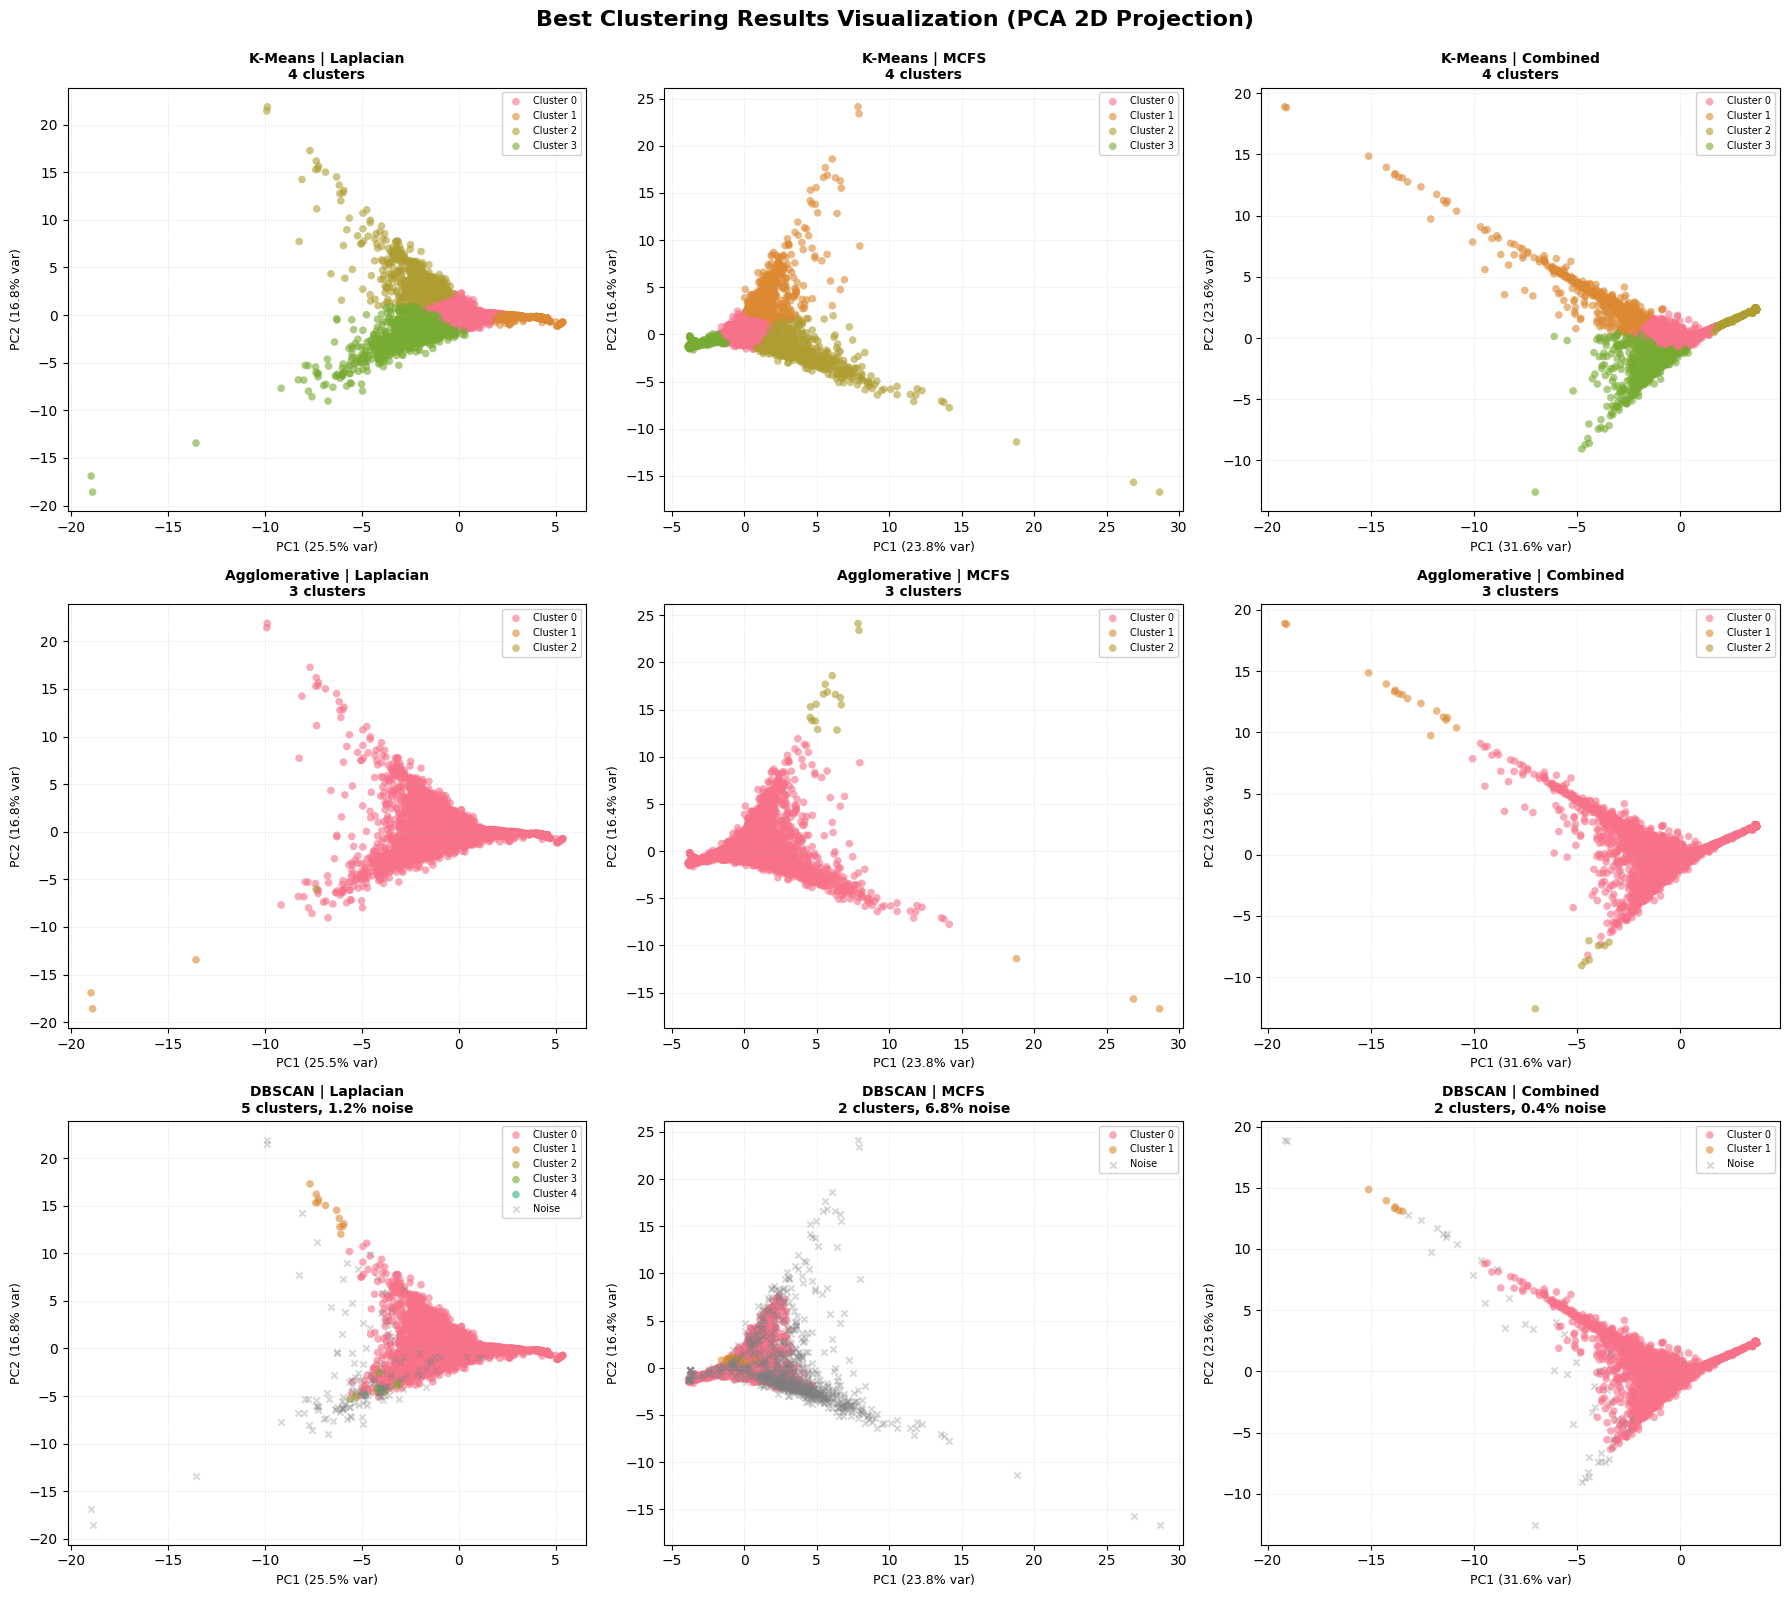

In [102]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

# ============================================================================
# STEP 2: Generate K-Means Labels (all k=4)
# ============================================================================
print("Generating K-Means labels...")

# Laplacian k=4
kmeans_laplacian = KMeans(n_clusters=4, init='k-means++', n_init=10, 
                          max_iter=300, random_state=42)
kmeans_labels_laplacian_k4 = kmeans_laplacian.fit_predict(df_laplacian.values)

# MCFS k=4
kmeans_mcfs = KMeans(n_clusters=4, init='k-means++', n_init=10, 
                     max_iter=300, random_state=42)
kmeans_labels_mcfs_k4 = kmeans_mcfs.fit_predict(df_mcfs.values)

# Combined k=4
kmeans_combined = KMeans(n_clusters=4, init='k-means++', n_init=10, 
                         max_iter=300, random_state=42)
kmeans_labels_combined_k4 = kmeans_combined.fit_predict(df_combined.values)

# ============================================================================
# STEP 3: Generate Agglomerative Labels (all k=3)
# ============================================================================
print("Generating Agglomerative labels...")

# Laplacian k=3, average linkage
agglom_laplacian = AgglomerativeClustering(n_clusters=3, linkage='average')
agglom_labels_laplacian_k3_avg = agglom_laplacian.fit_predict(df_laplacian.values)
# MCFS k=3, complete linkage
agglom_mcfs = AgglomerativeClustering(n_clusters=3, linkage='complete')
agglom_labels_mcfs_k3_complete = agglom_mcfs.fit_predict(df_mcfs.values)

# Combined k=3, complete linkage (or average - both had same score)
agglom_combined = AgglomerativeClustering(n_clusters=3, linkage='complete')
agglom_labels_combined_k3_complete = agglom_combined.fit_predict(df_combined.values)

# ============================================================================
# STEP 4: Generate DBSCAN Labels (different params for each)
# ============================================================================
print("Generating DBSCAN labels...")

# Laplacian: eps=2.5, min_samples=5
dbscan_laplacian = DBSCAN(eps=2.5, min_samples=5, metric='euclidean')
dbscan_labels_laplacian_eps25_min5 = dbscan_laplacian.fit_predict(df_laplacian.values)
# MCFS: eps=1.8, min_samples=30
dbscan_mcfs = DBSCAN(eps=1.8, min_samples=30, metric='euclidean')
dbscan_labels_mcfs_eps18_min30 = dbscan_mcfs.fit_predict(df_mcfs.values)

# Combined: eps=1.8, min_samples=5
dbscan_combined = DBSCAN(eps=1.8, min_samples=5, metric='euclidean')
dbscan_labels_combined_eps18_min5 = dbscan_combined.fit_predict(df_combined.values)

print("All labels generated successfully!")

# ============================================================================
# STEP 5: Now prepare the dictionaries for visualization
# ============================================================================

# K-Means results
kmeans_results = {
    'laplacian': kmeans_labels_laplacian_k4,
    'mcfs': kmeans_labels_mcfs_k4,
    'combined': kmeans_labels_combined_k4
}

# Agglomerative results
agglom_results = {
    'laplacian': agglom_labels_laplacian_k3_avg,
    'mcfs': agglom_labels_mcfs_k3_complete,
    'combined': agglom_labels_combined_k3_complete
}

# DBSCAN results
dbscan_results = {
    'laplacian': dbscan_labels_laplacian_eps25_min5,
    'mcfs': dbscan_labels_mcfs_eps18_min30,
    'combined': dbscan_labels_combined_eps18_min5
}

# ============================================================================
# STEP 6: Generate visualization
# ============================================================================
visualize_best_clustering_results(
    df_laplacian.values, 
    df_mcfs.values, 
    df_combined.values,
    kmeans_results,
    agglom_results,
    dbscan_results
)